# Uniform-Beam Optimization with SciBmad

### Fully-ionized tantalum ion bunch in the NSRL beamline; tune nonlinear optics to get transverse fluence approximately rectangular and uniform.
#### Use nonlinear optimization with flexible merit criteria.
#### Also, explore the effectiveness of perturbative rastering to improve uniformity.
#### Easily transformed to different energies and ion species for the HEET application.

At a high level, the workflow is:

1. Load Julia packages plus the local lattice and helper files.
2. Generate a quasi-random Gaussian input bunch from Sobol samples.
3. Track the bunch through the NSRL beamline using SciBmad.
4. Histogram the final `(x, y)` distribution and evaluate rectangular-target uniformity.
5. Use Xopt Bayesian optimization to vary `Q3`, `Q4`, and the paired octupoles.
6. Re-evaluate the selected solution and validate it on a larger independent Sobol sample.
7. Beginning with this optimized lattice, approximate rastering with a discrete convolution and 15% amplitude.
8. Use Xopt to optimize the rastering amplitude, independently for horizontal and vertical.
9. Use the optimal rastering amplitudes and go back to step 5, repeating the nonlinear optimization
10. Plot the evolution of two merit criteria through these various stages.

## Package Setup
<!-- codex-explanation-cell -->

The first cell installs notebook-side Julia dependencies if needed. On the JupyterHub server this is usually a one-time setup step.

The packages used later are:

- `Plots`: profile and heatmap visualization.
- `Sobol`: low-discrepancy sampling of initial particle coordinates.
- `StatsBase`: histogram binning and summary statistics.
- `StatsFuns`: inverse-normal transform for Sobol samples.
- `PythonCall`: bridge from Julia into Python/Xopt.

In [1]:
using Pkg
Pkg.add("Plots")
Pkg.add("Sobol")
Pkg.add("StatsBase")
Pkg.add("StatsFuns")
Pkg.add("PythonCall")
Pkg.add("CondaPkg")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.

In [2]:
using SciBmad 
using Plots
using StatsBase

## Local Beamline And Helper Files
<!-- codex-explanation-cell -->

`nsrl.jl` defines the physical beamline: tantalum ion species, reference energy, dipoles, quadrupoles, octupoles, drifts, and rectangular aperture limits.

`helpers.jl` contains notebook utilities: Sobol-based bunch generation, 2D histogram plotting, rectangular cutout extraction, and the beam-uniformity merit functions used by the optimizer.

In [3]:
include("nsrl.jl")

In [4]:
include("helpers.jl")

hist

## Initial Bunch Generation
<!-- codex-explanation-cell -->

This block creates the incoming 6D particle array passed to SciBmad.

The transverse phase space is built as follows:

- `sobol_normals(N, 4)` generates quasi-random standard-normal samples.
- The first two dimensions become the horizontal coordinates `(x, px)`.
- The next two dimensions become the vertical coordinates `(y, py)`.
- `Mx` and `My` apply the selected Twiss parameters and emittances.
- The longitudinal coordinates are set to zero, producing columns `[x, px, y, py, z, pz]`.

Using Sobol samples reduces random Monte Carlo noise compared with ordinary pseudorandom particles, which is helpful because histogram uniformity is being used as an optimization merit function.

In [5]:
# Use 4 dims: 2 for x-plane, 2 for y-plane
N = 50_000
Z = sobol_normals(N, 4)
Zx = Z[:, 1:2]
Zy = Z[:, 3:4]

epsilon_a = 7.7e-6
epsilon_b = 7.7e-6

beta_a = 7
beta_b = 8
alpha_a = -0.3
alpha_b = -0.8


Mx = [sqrt(beta_a) 0; -alpha_a/sqrt(beta_a) 1/sqrt(beta_a)]
My = [sqrt(beta_b) 0; -alpha_b/sqrt(beta_b) 1/sqrt(beta_b)]


coords_x = sqrt(epsilon_a) .* (Zx * Mx')
coords_y = sqrt(epsilon_b) .* (Zy * My')
coords_z = zeros(N, 2)

coords = hcat(coords_x, coords_y, coords_z);

## Particle Distribution before tracking
<!-- codex-explanation-cell -->

These cells make quick visual checks before and after tracking.

`hist(coords, ...)` shows the initial transverse distribution. Then `track(nsrl, coords)` sends the bunch through the SciBmad beamline, and the next histogram shows the final `(x, y)` beam profile at the target plane.

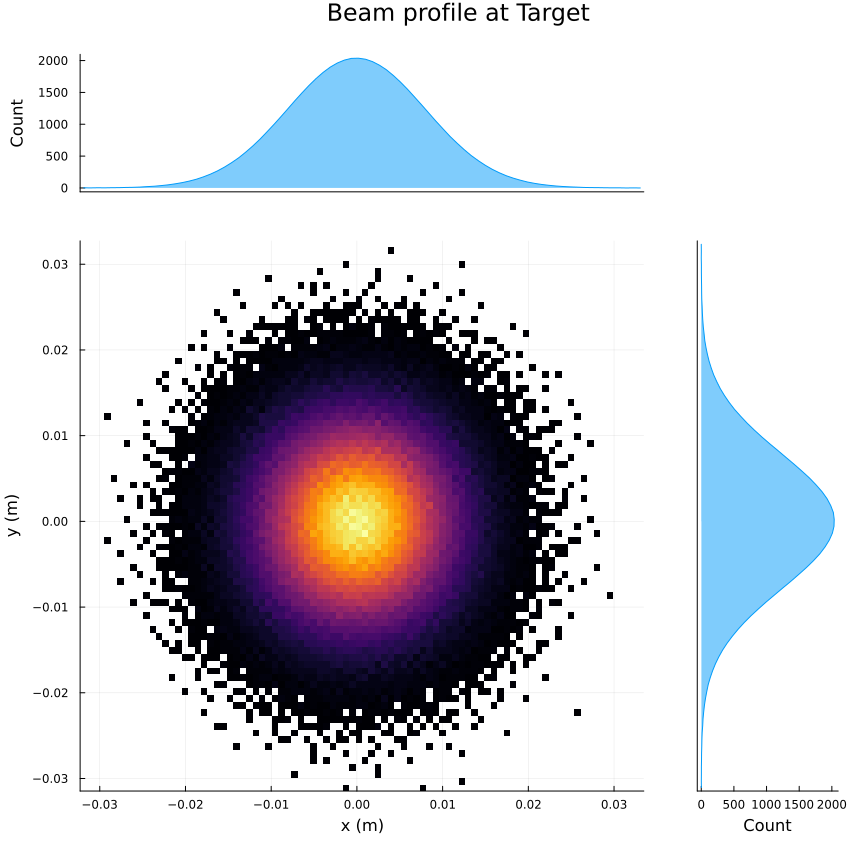

In [6]:
hist(coords, nx=80, ny=80, xlims=nothing, ylims=nothing, make_plot=true, cutout=false)["figure"]

## Track the particle distribution through the lattice

In [7]:
bunch = track(nsrl, coords);

## Particle Distribution after tracking

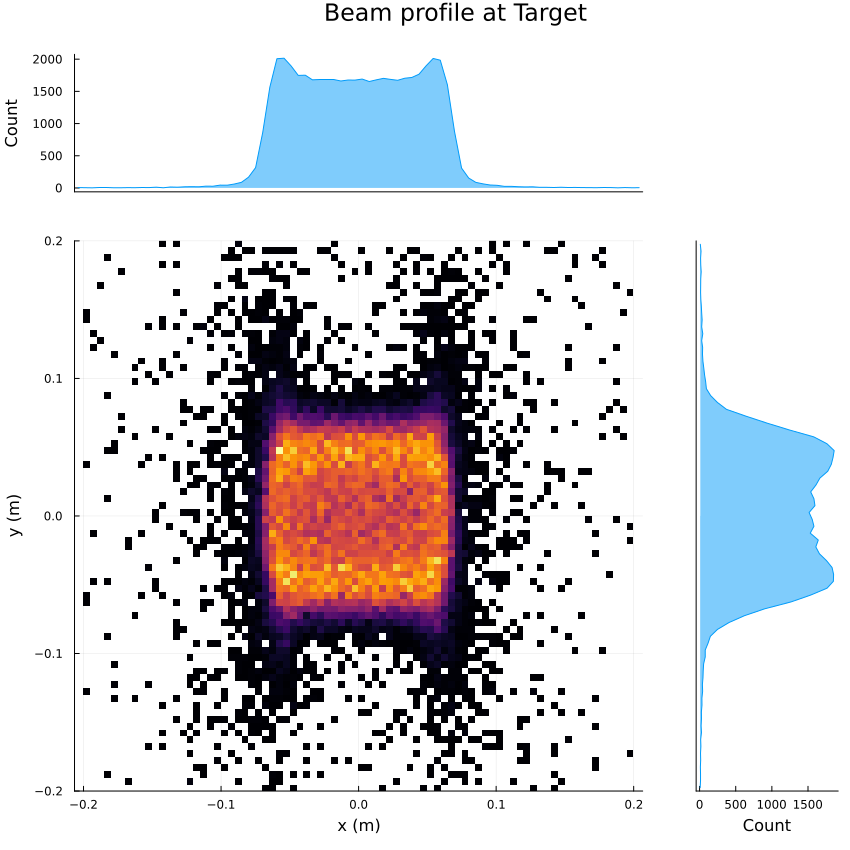

In [8]:
hist(bunch, nx=80, ny=80)["figure"]

## Rectangular Target And Uniformity Metrics
<!-- codex-explanation-cell -->

The target region is represented by a centered rectangular cutout of the final `(x, y)` histogram.

The keyword values `h` and `v` are half-widths in meters. For example, `h = 0.07`, `v = 0.07` evaluates a `14 cm x 14 cm` square centered on `(0, 0)`.

The original metric is:

```julia
frac = sum(box_counts) / n_total
cv_raw = std(box_counts) / mean(box_counts)
```

The improved helper `uniformity_metrics(...)` also reports shot-noise-corrected CV, shifted-grid CV, cloud-in-cell smoothed CV, direct in-box fraction, top-hat RMSE, leakage, and capture penalties. This makes it easier to distinguish a genuinely flat distribution from artifacts caused by finite particle count or arbitrary histogram bin edges.

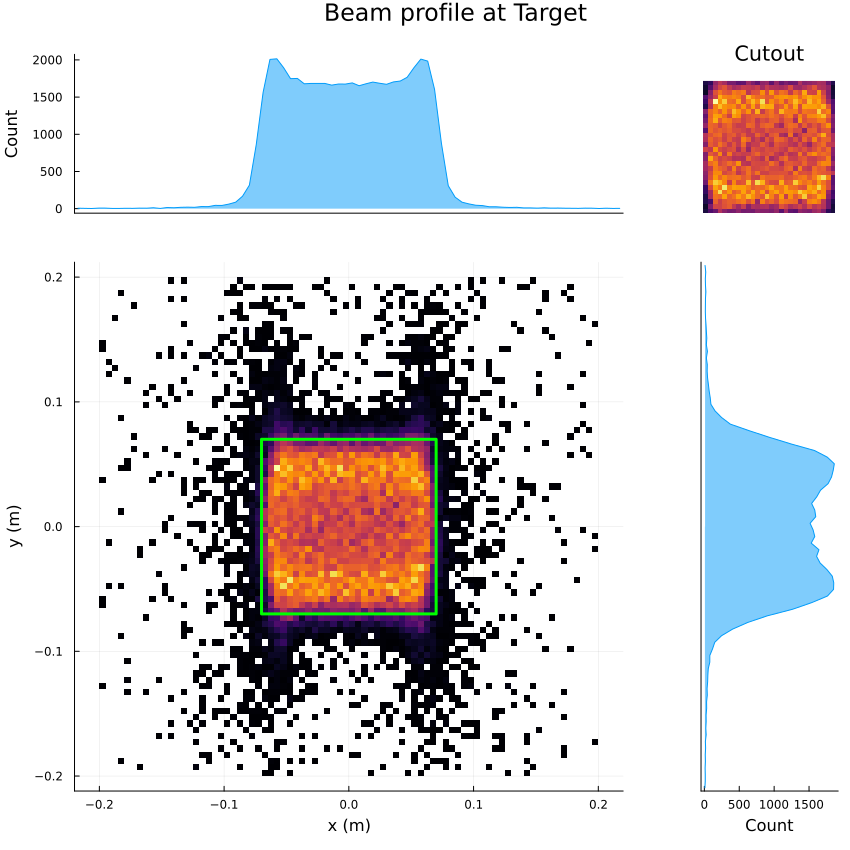

In [9]:
p0 = hist(
    bunch, 
    nx=80, ny=80,
    h=0.07, v=0.07,
    cutout=true
);

p0["figure"]

In [10]:
cutout = hist(
    bunch, 
    nx=80, ny=80,
    h=0.05, v=0.05,
    cutout=true,
    make_plot=false
)

Dict{String, Any} with 9 entries:
  "n_total"   => 50000
  "y_centers" => -0.1975:0.005:0.1975
  "x_edges"   => -0.2:0.005:0.2
  "x_centers" => -0.1975:0.005:0.1975
  "cutout"    => [65.0 73.0 … 72.0 77.0; 89.0 69.0 … 75.0 71.0; … ; 72.0 69.0 ……
  "y_edges"   => -0.2:0.005:0.2
  "center"    => (0.0, 0.0)
  "h_indices" => 31:50
  "v_indices" => 31:50

In [11]:
cutout_hist = cutout["cutout"]
n_particles = cutout["n_total"]
metrics0 = uniformity_metrics(bunch, nx=80, ny=80, h=0.05, v=0.05)

println("Original histogram-bin summary:")
println("Portion of total: ", sum(cutout_hist) / n_particles * 100, " %")
println("Mean: ", round(mean(cutout_hist), digits=3))
println("STD: ", round(std(cutout_hist), digits=3))
println("Max: ", maximum(cutout_hist), "  Min: ", minimum(cutout_hist))

println("\nImproved uniformity metrics:")
print_uniformity_metrics(metrics0)

Original histogram-bin summary:
Portion of total: 47.666 %
Mean: 59.582
STD: 9.257
Max: 89.0  Min: 36.0

Improved uniformity metrics:
objective              0.9900
frac_exact             0.4767
frac_hist              0.4767
cv_raw                 0.1554
cv_excess              0.0854
cv_shifted_excess      0.0858
cv_shifted_spread      0.0034
cv_cic                 0.1252
top_hat_rmse           0.6855
leakage                0.5233
capture_shortfall      0.2233
capture_penalty        0.4988


In [12]:
# The original metric now lives in helpers.jl so it can be compared with
# the shot-noise-corrected estimate used by the improved objective.
box_merit(cutout), box_merit_excess_cv(cutout)

((0.47666, 0.155360207320298), (0.47666, 0.08539906625224324))

In [13]:
uniformity_metrics(bunch, nx=80, ny=80, h=0.05, v=0.05)

Dict{String, Real} with 13 entries:
  "leakage"           => 0.52334
  "objective"         => 0.989982
  "frac_exact"        => 0.47666
  "cv_shifted_excess" => 0.0858144
  "cv_raw"            => 0.15536
  "capture_shortfall" => 0.22334
  "n_shifted_grids"   => 5
  "frac_hist"         => 0.47666
  "top_hat_rmse"      => 0.685534
  "cv_shifted_spread" => 0.00338899
  "cv_excess"         => 0.0853991
  "cv_cic"            => 0.125185
  "capture_penalty"   => 0.498808

## Python/Xopt Bridge
<!-- codex-explanation-cell -->

Xopt is a Python optimization library. These cells install/import Xopt into the Julia session through `PythonCall`, then expose the Python classes used later:

- `VOCS`: declares variables, objectives, constraints, and observables.
- `Evaluator`: wraps the Julia merit function so Xopt can call it.
- `ExpectedImprovementGenerator`: Bayesian optimization generator.

The optimizer therefore lives in Python, while the tracking and merit calculation remain in Julia.

In [14]:
import CondaPkg
CondaPkg.add("xopt"; channel="conda-forge")
# CondaPkg.add("numpy"; channel="conda-forge")
# CondaPkg.add("builtins"; channel="conda-forge")

    CondaPkg Found dependencies: /home/vagrant/.julia/environments/v1.12/CondaPkg.toml
    CondaPkg Found dependencies: /home/vagrant/.julia/packages/CondaPkg/lKlVY/CondaPkg.toml
    CondaPkg Found dependencies: /home/vagrant/.julia/packages/PythonCall/JksWe/CondaPkg.toml
    CondaPkg Initialising pixi
             │ /home/vagrant/.julia/artifacts/4ae17cee0bd922f66b2c72bf2f01c22481a5ec19/bin/pixi
             │ init
             │ --format pixi
             └ /home/vagrant/.julia/environments/v1.12/.CondaPkg
Created /home/vagrant/.julia/environments/v1.12/.CondaPkg/pixi.toml
    CondaPkg Wrote /home/vagrant/.julia/environments/v1.12/.CondaPkg/pixi.toml
             │ [dependencies]
             │ openssl = ">=3, <3.6"
             │ libstdcxx = ">=3.4,<=15.1"
             │ libstdcxx-ng = ">=3.4,<=15.1"
             │ 
             │     [dependencies.xopt]
             │     channel = "conda-forge"
             │     version = "*"
             │ 
             │     [dependencies.pytho

In [15]:
using PythonCall
xopt = pyimport("xopt");
np = pyimport("numpy");
# pydict = pyimport("builtins").dict;
pybuiltins = pyimport("builtins")
pydict = pybuiltins.dict;

In [16]:
# Bind Python Xopt classes into Julia names used below.
Xopt = xopt.Xopt
VOCS = xopt.vocs.VOCS
Evaluator = xopt.evaluator.Evaluator
bayesian = pyimport("xopt.generators.bayesian")
ExpectedImprovementGenerator = bayesian.ExpectedImprovementGenerator

Python: <class 'xopt.generators.bayesian.expected_improvement.ExpectedImprovementGenerator'>

## Optimization Variables
<!-- codex-explanation-cell -->

The optimizer varies three machine settings:

- `x1`: `Q3.Bn1`, the Q3 quadrupole gradient.
- `x2`: `Q4.Bn1`, the Q4 quadrupole gradient.
- `x3`: octupole strength magnitude, applied as `O1.Bn3 = -x3` and `O2.Bn3 = x3`.

The single objective `f` is minimized. The evaluator also returns diagnostic columns such as `frac`, `cv_shifted`, `cv_cic`, `top_hat_rmse`, and `leakage`, so the optimization result can be inspected rather than treated as a black box.

In [17]:
variables = pydict(pylist([
    ("x1", pylist([2.0, 4.0])),
    ("x2", pylist([-4.0, -2.0])),
    ("x3", pylist([1250.0, 2250.0])),
]))

objectives = pydict(pylist([
    ("f", "MINIMIZE"),
]))

vocs = VOCS(; variables=variables, objectives=objectives)

pytype(vocs.variables), pytype(vocs.objectives)
pyrepr(vocs.variables)

Python: "{'x1': ContinuousVariable(dtype=None, default_value=None, domain=[2.0, 4.0]), 'x2': ContinuousVariable(dtype=None, default_value=None, domain=[-4.0, -2.0]), 'x3': ContinuousVariable(dtype=None, default_value=None, domain=[1250.0, 2250.0])}"

## Objective Function Evaluation
<!-- codex-explanation-cell -->

For each trial point proposed by Xopt, `func(x)` does four things:

1. Writes the proposed settings into the SciBmad lattice elements.
2. Tracks the same input bunch through the updated beamline.
3. Computes the improved uniformity metrics inside the target rectangle.
4. Returns a Python dictionary whose `f` entry is a balanced scalar objective combining normalized `CV raw` and normalized `Top-hat RMSE`, with modest captured-fraction and leakage guardrails.

`f_legacy` is also returned for comparison with the earlier merit function. The diagnostic columns `f_cv_term`, `f_rmse_term`, and penalty terms show why Xopt preferred a given trial point.

In [18]:
# Explicit optics merit function weights.
# The optimized scalar `f` balances in-box uniformity against full-field
# rectangular top-hat agreement, instead of relying on the helper default.
optics_nx = 80
optics_ny = 80
optics_target_h = 0.07
optics_target_v = 0.07

optics_cv_weight = 0.50
optics_rmse_weight = 0.50
optics_balance_weight = 0.15
optics_capture_goal = 0.72
optics_leakage_goal = 1.0 - optics_capture_goal
optics_capture_penalty_weight = 6.0
optics_leakage_penalty_weight = 3.0

reference_metrics = uniformity_metrics(
    bunch;
    nx=optics_nx, ny=optics_ny,
    h=optics_target_h, v=optics_target_v,
)

reference_cv_blend = max(
    0.75 * reference_metrics["cv_raw"] + 0.25 * reference_metrics["cv_cic"],
    eps(Float64),
)
reference_top_hat_rmse = max(reference_metrics["top_hat_rmse"], eps(Float64))

function func(x)
    Q3.Bn1 =  x["x1"]
    Q4.Bn1 =  x["x2"]
    O1.Bn3 = -x["x3"]
    O2.Bn3 =  x["x3"]
    
    tmp = track(nsrl, coords)
    metrics = uniformity_metrics(
        tmp;
        nx=optics_nx, ny=optics_ny,
        h=optics_target_h, v=optics_target_v,
        capture_goal=optics_capture_goal,
        capture_weight=0.0,
        shifted_weight=0.0,
        smooth_weight=0.0,
        top_hat_weight=0.0,
    )

    cv_blend = 0.75 * metrics["cv_raw"] + 0.25 * metrics["cv_cic"]
    cv_term = cv_blend / reference_cv_blend
    rmse_term = metrics["top_hat_rmse"] / reference_top_hat_rmse
    balance_penalty = optics_balance_weight * abs(cv_term - rmse_term)

    capture_shortfall = max(optics_capture_goal - metrics["frac_exact"], 0.0)
    leakage_excess = max(metrics["leakage"] - optics_leakage_goal, 0.0)
    capture_penalty = optics_capture_penalty_weight * capture_shortfall^2
    leakage_penalty = optics_leakage_penalty_weight * leakage_excess^2

    objective = optics_cv_weight * cv_term +
                optics_rmse_weight * rmse_term +
                balance_penalty +
                capture_penalty +
                leakage_penalty

    legacy_f = metrics["cv_raw"] + exp(25 * (0.7 - metrics["frac_hist"]))
    
    return pydict(Dict(
        "f" => objective,
        "f_legacy" => legacy_f,
        "f_cv_term" => cv_term,
        "f_rmse_term" => rmse_term,
        "f_balance_penalty" => balance_penalty,
        "f_capture_penalty" => capture_penalty,
        "f_leakage_penalty" => leakage_penalty,
        "frac" => metrics["frac_exact"],
        "frac_hist" => metrics["frac_hist"],
        "cv_raw" => metrics["cv_raw"],
        "cv_blend" => cv_blend,
        "cv_excess" => metrics["cv_excess"],
        "cv_shifted" => metrics["cv_shifted_excess"],
        "cv_cic" => metrics["cv_cic"],
        "top_hat_rmse" => metrics["top_hat_rmse"],
        "leakage" => metrics["leakage"],
        "capture_shortfall" => capture_shortfall,
        "leakage_excess" => leakage_excess,
    ))
end

func (generic function with 1 method)

## Bayesian Optimization Run
<!-- codex-explanation-cell -->

These cells create the Xopt object, seed it with a few initial settings, and then run repeated `X.step()` calls.

Each step asks the Bayesian model for a promising new setting, evaluates the SciBmad tracking merit, stores the result in `X.data`, and updates the surrogate model. After the loop, the notebook extracts the row with the smallest objective value.

In [19]:
evaluator = Py(Evaluator(; :function => func))

generator = ExpectedImprovementGenerator(; :vocs => vocs, :turbo_controller => "optimize")
generator.gp_constructor.use_low_noise_prior = true

X = Xopt(; :evaluator => evaluator, :generator => generator, :vocs => vocs)

_tmp = pydict(Dict(
    "x1" =>  [3.0, 2.0, 2.0, 4.0, 4.0],
    "x2" => [-3.0, -4.0, -2.0, -2.0, -4.0],
    "x3" => [1.75e3, 1.75e3, 1.75e3, 1.75e3, 1.75e3]
))

X.evaluate_data(_tmp)

,x1,x2,x3,f,leakage,f_capture_penalty,cv_raw,cv_shifted,f_leakage_penalty,capture_shortfall,leakage_excess,frac_hist,frac,top_hat_rmse,f_balance_penalty,cv_blend,f_cv_term,f_legacy,cv_excess,cv_cic,f_rmse_term,xopt_runtime,xopt_error
0,3.0,-3.0,1750.0,0.960091,0.11174,0.000000,0.252635,0.217010,0.000000,0.00000,0.00000,0.88826,0.88826,0.283125,0.000686,0.247997,0.961693,0.261671,0.214687,0.234083,0.957118,3.609125,False
1,2.0,-4.0,1750.0,4.738640,0.75280,1.341239,0.726072,0.679370,0.670620,0.47280,0.47280,0.24720,0.24720,0.779602,0.021070,0.715847,2.775944,82455.068993,0.680498,0.685174,2.635479,0.076372,False
2,2.0,-2.0,1750.0,2.640685,0.35924,0.037674,0.743645,0.727803,0.018837,0.07924,0.07924,0.64076,0.64076,0.607619,0.122329,0.740001,2.869607,5.140986,0.726521,0.729067,2.054083,0.076526,False
3,4.0,-2.0,1750.0,3.020023,0.40640,0.095862,0.839898,0.823912,0.047931,0.12640,0.12640,0.59360,0.59360,0.649217,0.157275,0.836342,3.243205,15.136187,0.823476,0.825676,2.194707,0.077062,False
4,4.0,-4.0,1750.0,4.915384,0.39870,0.084538,1.445557,1.437520,0.042269,0.11870,0.11870,0.60130,0.60130,0.974801,0.344589,1.442198,5.592618,13.238485,1.435581,1.432119,3.295357,0.084191,False


In [20]:
start_time = time()
@time for i in 1:100
    X.step()
    if i%10 == 0
        println("$i steps complete: $(time() - start_time) seconds")
    end
end
println("Bayesian optimization complete")

10 steps complete: 32.73294377326965 seconds
20 steps complete: 70.4723448753357 seconds
30 steps complete: 107.95060777664185 seconds
40 steps complete: 147.35555791854858 seconds
50 steps complete: 179.1204798221588 seconds
60 steps complete: 218.17774891853333 seconds
70 steps complete: 262.4660029411316 seconds
80 steps complete: 282.1613848209381 seconds
90 steps complete: 295.89881682395935 seconds
100 steps complete: 314.49217987060547 seconds
314.437154 seconds (211.10 k allocations: 922.871 MiB, 0.20% gc time, 0.01% compilation time)
Bayesian optimization complete


In [21]:
mask = X.data["f"] .== X.data["f"].min()
ind = X.data["f"].index[mask][0]
py_series = X.data.loc[ind]

keys = collect(py_series.index)
values = collect(py_series.values)

jl_dict = Dict(string(k) => v for (k, v) in zip(keys, values))

Dict{String, Py} with 23 entries:
  "f"                 => np.float64(0.8561176534209379)
  "leakage"           => np.float64(0.13529999999999998)
  "f_capture_penalty" => np.float64(0.0)
  "xopt_error"        => np.False_
  "x3"                => np.float64(1601.4115910704631)
  "f_balance_penalty" => np.float64(0.026380382329837065)
  "cv_blend"          => np.float64(0.1912925388176051)
  "f_legacy"          => np.float64(0.21238474455647527)
  "cv_excess"         => np.float64(0.14238164942003811)
  "f_rmse_term"       => np.float64(0.9176718788572243)
  "x2"                => np.float64(-2.9424856070716614)
  "cv_raw"            => np.float64(0.19609956802198303)
  "cv_shifted"        => np.float64(0.14987545610289418)
  "f_leakage_penalty" => np.float64(0.0)
  "capture_shortfall" => np.float64(0.0)
  "leakage_excess"    => np.float64(0.0)
  "xopt_runtime"      => np.float64(0.0780225321650505)
  "frac_hist"         => np.float64(0.8647)
  "frac"              => np.float64(0.8647)

## Best Candidate Before/After Comparison
<!-- codex-explanation-cell -->

This block applies the best settings found by Xopt back to the beamline, tracks the optimization bunch again, prints the metric breakdown, and plots the baseline and optimized beam profiles side by side.

This is the first place to check whether the optimizer found a physically plausible rectangular distribution, not just a low scalar objective.

Best candidate metrics on optimization sample:
objective              0.3740
frac_exact             0.8647
frac_hist              0.8647
cv_raw                 0.1961
cv_excess              0.1424
cv_shifted_excess      0.1499
cv_shifted_spread      0.0046
cv_cic                 0.1769
top_hat_rmse           0.2715
leakage                0.1353
capture_shortfall      0.0000
capture_penalty        0.0000


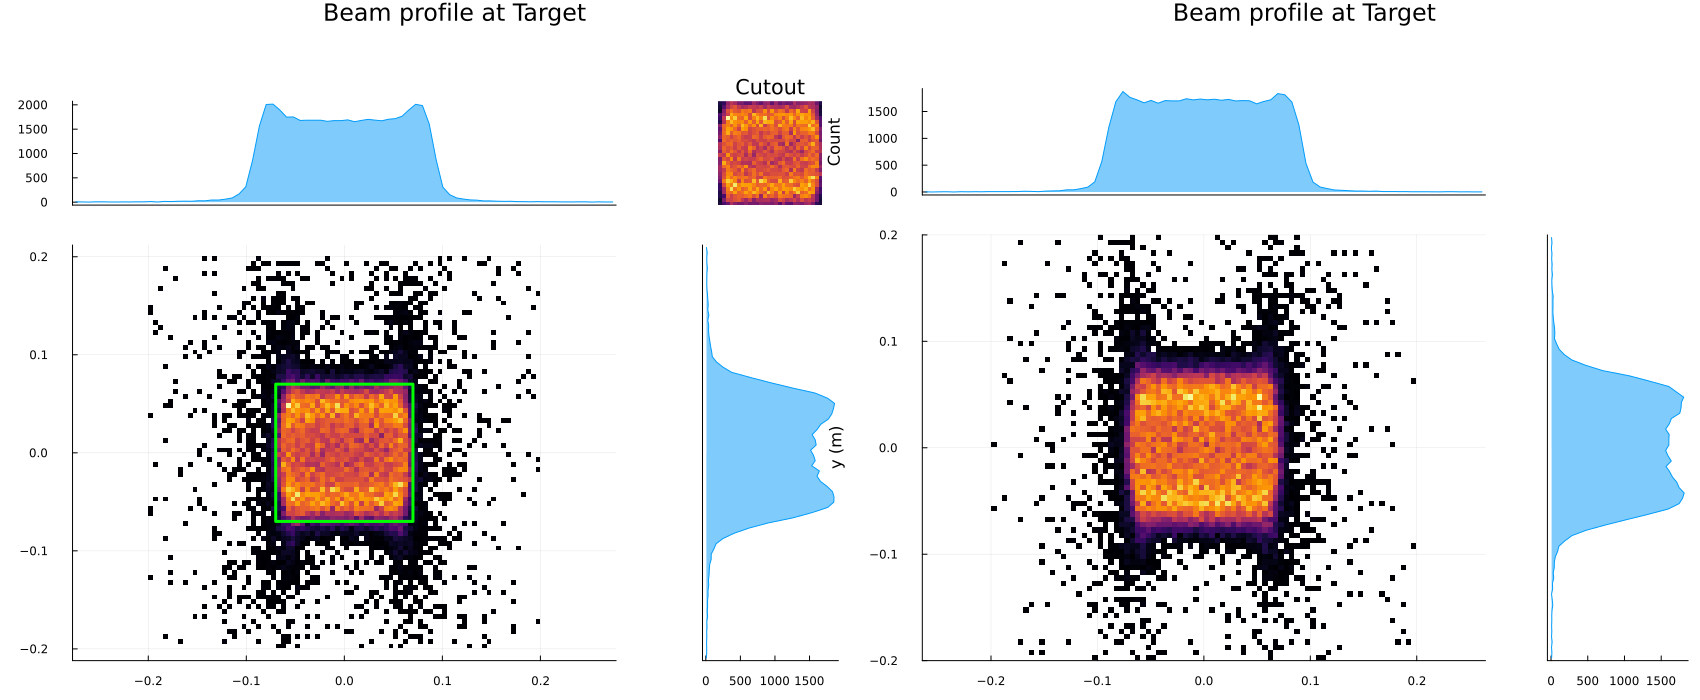

In [22]:
Q3.Bn1 =  pyconvert(Float64, jl_dict["x1"]) #2.967012114407703 
Q4.Bn1 =  pyconvert(Float64, jl_dict["x2"]) #-2.95254862450049 
O1.Bn3 = -pyconvert(Float64, jl_dict["x3"]) #-1490.8026736329402 
O2.Bn3 =  pyconvert(Float64, jl_dict["x3"]) #1490.8026736329402 


tmp = track(nsrl, coords)
best_metrics = uniformity_metrics(tmp, nx=80, ny=80, h=0.07, v=0.07)

println("Best candidate metrics on optimization sample:")
print_uniformity_metrics(best_metrics)

p_tmp = hist(tmp, nx=80, ny=80, h=0.07, v=0.07);


plot(p0["figure"], p_tmp["figure"], size=(1700, 700))

## Independent Validation Sample
<!-- codex-explanation-cell -->

The optimizer repeatedly evaluates the same finite Sobol sample, so a good setting can partly benefit from sample-specific histogram details.

This validation block generates a larger independent Sobol bunch using `skip=N + 10_000`, tracks it with the selected machine settings, and recomputes the same uniformity metrics. Agreement between the optimization-sample metrics and validation metrics is evidence that the result is robust rather than overfit to one particle sample.

In [23]:
N_validation = 200_000
Z_validation = sobol_normals(N_validation, 4; skip=N + 10_000)
Zx_validation = Z_validation[:, 1:2]
Zy_validation = Z_validation[:, 3:4]

coords_x_validation = sqrt(epsilon_a) .* (Zx_validation * Mx')
coords_y_validation = sqrt(epsilon_b) .* (Zy_validation * My')
coords_z_validation = zeros(N_validation, 2)
coords_validation = hcat(coords_x_validation, coords_y_validation, coords_z_validation)

bunch_validation = track(nsrl, coords_validation)
validation_metrics = uniformity_metrics(bunch_validation, nx=80, ny=80, h=0.07, v=0.07)

println("Validation metrics on independent larger sample:")
print_uniformity_metrics(validation_metrics)

Validation metrics on independent larger sample:
objective              0.3761
frac_exact             0.8636
frac_hist              0.8636
cv_raw                 0.1739
cv_excess              0.1602
cv_shifted_excess      0.1630
cv_shifted_spread      0.0015
cv_cic                 0.1670
top_hat_rmse           0.2593
leakage                0.1364
capture_shortfall      0.0000
capture_penalty        0.0000


## Parameter Scans
<!-- codex-explanation-cell -->

The final scan blocks sweep selected magnet settings and plot heatmaps of capture fraction and uniformity.

These scans are slower than a single optimizer run, but they are useful for understanding the local landscape: where the solution is stable, where it is sensitive, and how strongly the quadrupoles and octupoles trade off against one another.

In [24]:
merit_size = Array{Float64}(undef, 21, 21, 3, 2)

for (i, q3_b1) in enumerate(2:0.1:4)
    Q3.Bn1 = q3_b1
    for (j, q4_b1) in enumerate(-2:-0.1:-4)
        Q4.Bn1 = q4_b1
        
        tmp = track(nsrl, coords)
        
        for (k, len) in enumerate(0.05:0.01:0.07)
            try
                cutout_tmp = hist(
                    tmp, 
                    h=len, v=len,
                    nx=80, ny=80, 
                    cutout=true,
                    make_plot=false
                )
                merit_size[i, j, k, :] .= box_merit(cutout_tmp)
                
            catch
                merit_size[i, j, k, :] .= [NaN, NaN]
            end
        end
    end
end

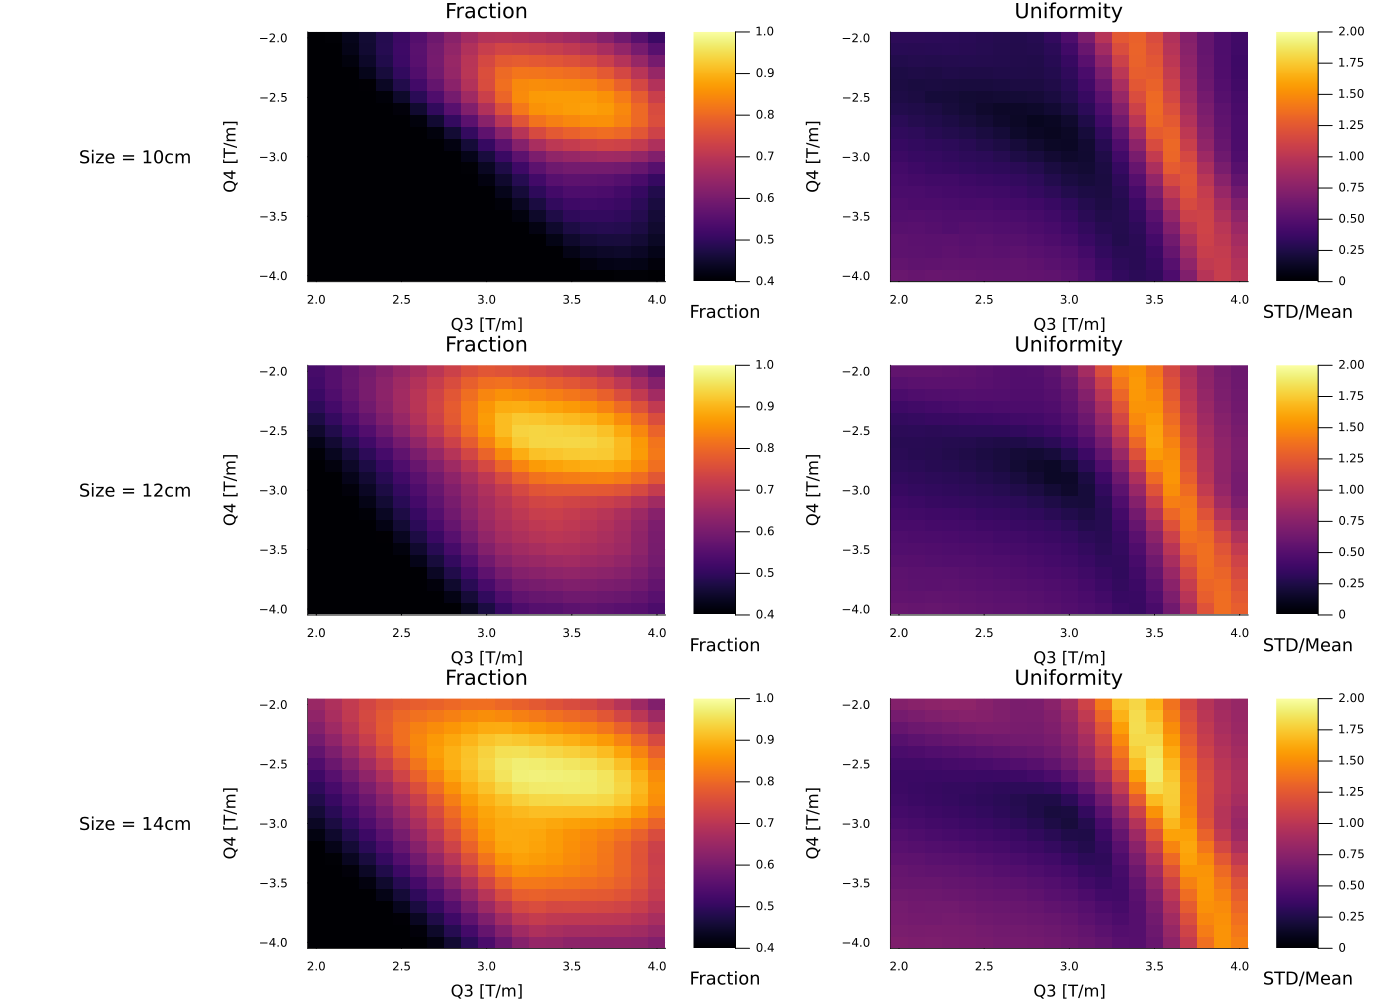

In [25]:
# Create plots for all 5 slices from the 3rd dimension
all_plots = []

for k in 1:3
    p_blank = plot(framestyle=:none, axis=false)
    annotate!(p_blank, 0.5, 0.5, text("Size = $(8+2*k)cm", :center, 12))

    p_left = heatmap(2:0.1:4, -4:0.1:-2, merit_size[:, end:-1:1, k, 1]', 
                     xlabel="Q3 [T/m]", ylabel="Q4 [T/m]", 
                     clims=(0.4, 1.0),
                     title="Fraction")
    annotate!(p_left, 4.4, -4.3, text("Fraction", :center, 12))
    
    p_right = heatmap(2:0.1:4, -4:0.1:-2, merit_size[:, end:-1:1, k, 2]', 
                      xlabel="Q3 [T/m]", ylabel="Q4 [T/m]", 
                      clims=(0.0, 2.0),
                      title="Uniformity")
    annotate!(p_right, 4.4, -4.3, text("STD/Mean", :center, 12))
    
    push!(all_plots, p_blank)
    push!(all_plots, p_left)
    push!(all_plots, p_right)
end

# Create layout with all plots: 5 rows, 3 columns with custom widths
l = grid(3, 3, heights=repeat([1/3], 3), widths=[0.15, 0.425, 0.425])
plot(all_plots..., layout=l, size=(1400, 1000))

In [26]:
merit_oct = Array{Float64}(undef, 21, 21, 5, 2)

for (i, q3_b1) in enumerate(2:0.1:4)
    Q3.Bn1 = q3_b1
    for (j, q4_b1) in enumerate(-2:-0.1:-4)
        Q4.Bn1 = q4_b1
        for (k, o_b3) in enumerate(1250:250:2250)
            O1.Bn3 = -o_b3
            O2.Bn3 =  o_b3

            tmp = track(nsrl, coords)
            
            try 
                cutout_tmp = hist(
                    tmp, 
                    nx=80, ny=80, 
                    cutout=true, 
                    make_plot=false
                )
                merit_oct[i, j, k, :] .= box_merit(cutout_tmp)
            catch
                println("Q3.Bn1 = ", q3_b1)
                println("Q4.Bn1 = ", q4_b1)
                println("O.Bn3  = ", o_b3)
                merit_oct[i, j, k, :] .= [NaN, NaN]
            end
        end
    end
end

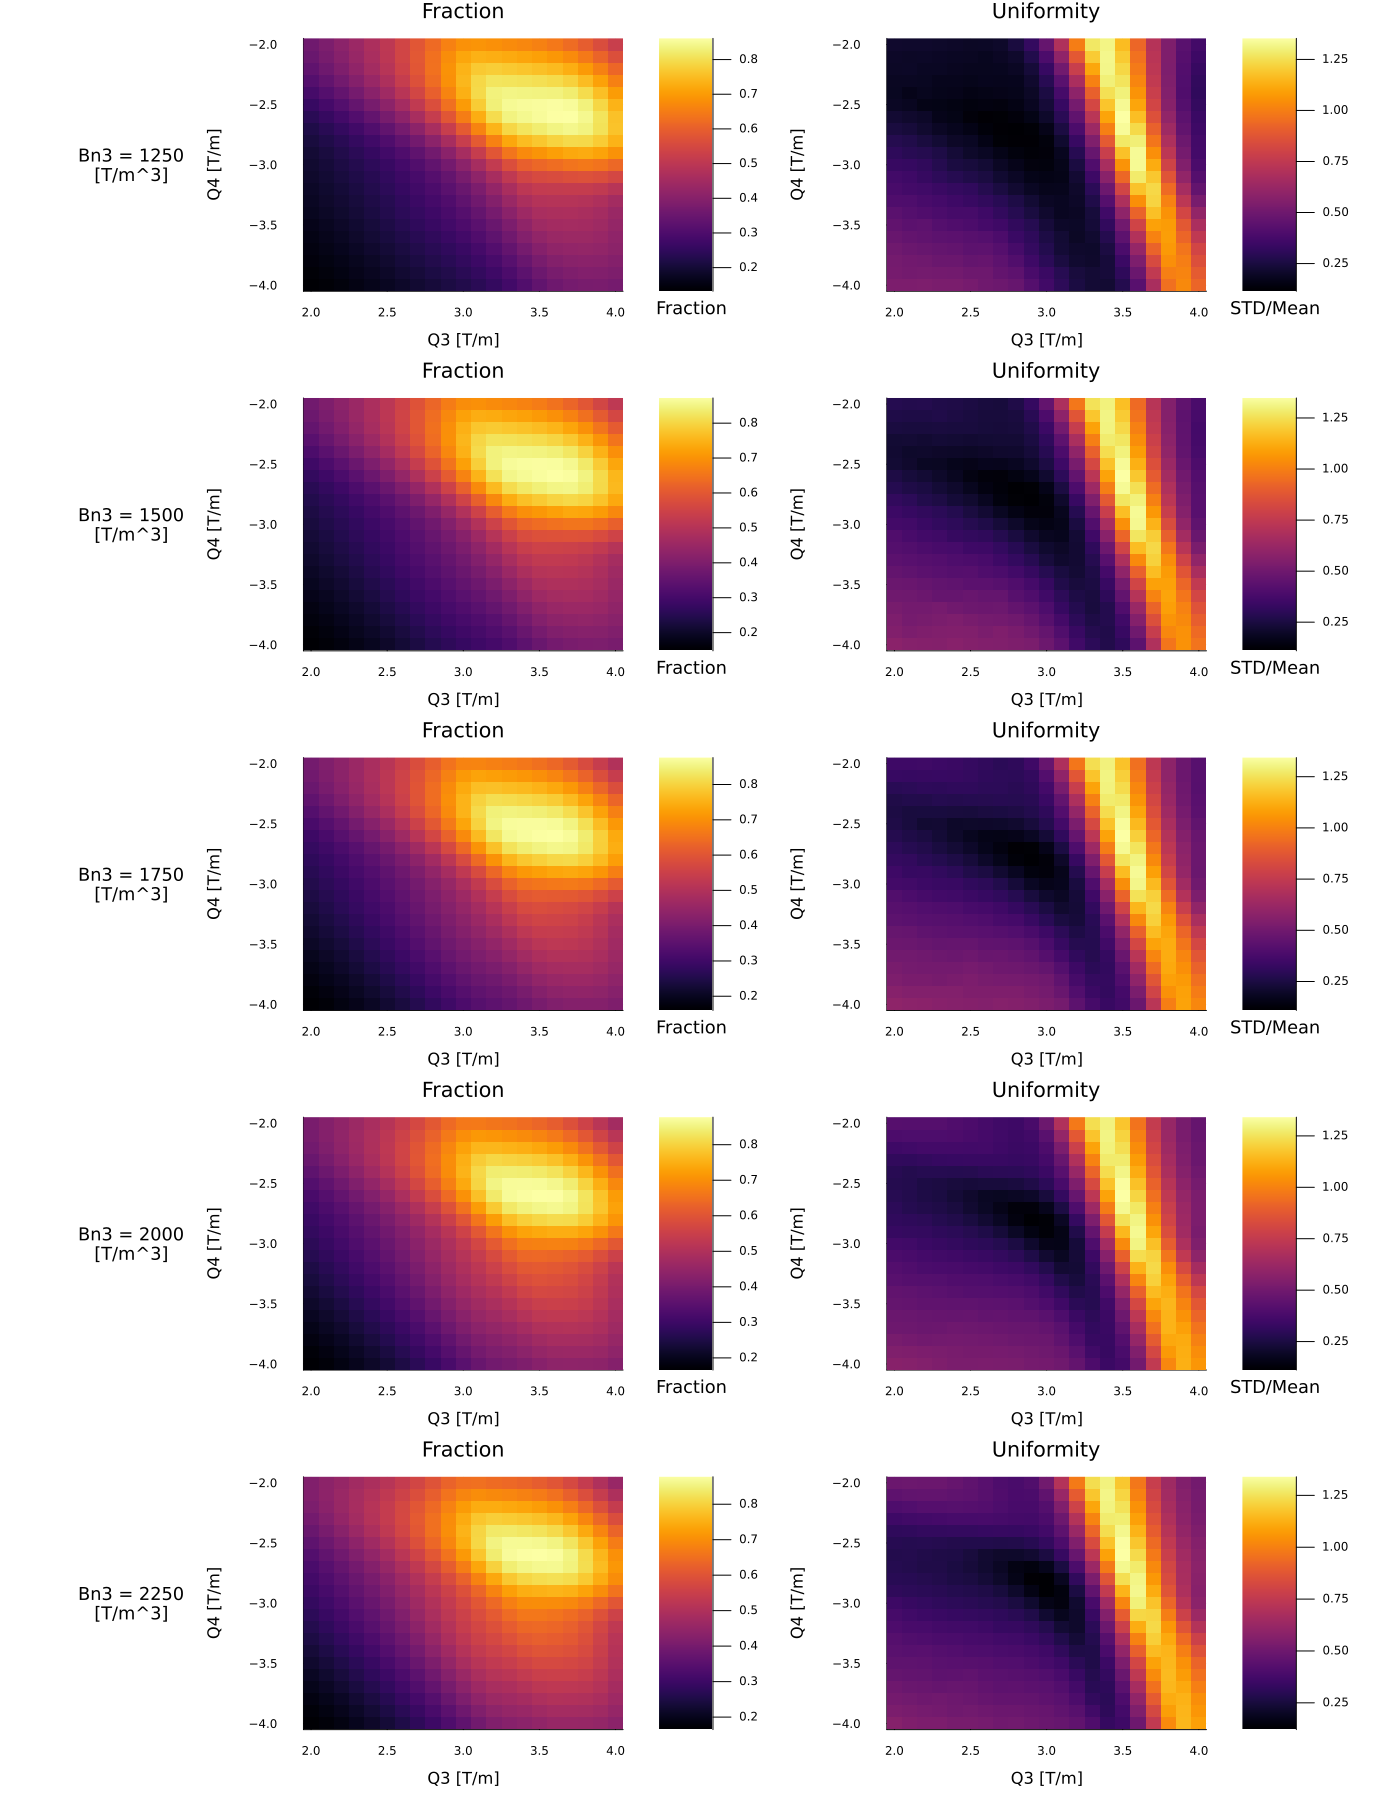

In [27]:
# Create plots for all 5 slices from the 3rd dimension
all_plots = []

for k in 1:5
    p_blank = plot(framestyle=:none, axis=false)
    annotate!(p_blank, 0.5, 0.5, text("Bn3 = $(1250+250*(k-1))\n[T/m^3]", :center, 12))

    p_left = heatmap(2:0.1:4, -4:0.1:-2, merit_oct[:, end:-1:1, k, 1]', 
                     xlabel="Q3 [T/m]", ylabel="Q4 [T/m]", 
                     title="Fraction")
    annotate!(p_left, 4.5, -1.2, text("Fraction", :center, 12))
    
    p_right = heatmap(2:0.1:4, -4:0.1:-2, merit_oct[:, end:-1:1, k, 2]', 
                      xlabel="Q3 [T/m]", ylabel="Q4 [T/m]", 
                      title="Uniformity")
    annotate!(p_right, 4.5, -1.2, text("STD/Mean", :center, 12))
    
    push!(all_plots, p_blank)
    push!(all_plots, p_left)
    push!(all_plots, p_right)
end

# Create layout with all plots: 5 rows, 3 columns with custom widths
l = grid(5, 3, heights=repeat([1/5], 5), widths=[0.15, 0.425, 0.425])
plot(all_plots..., layout=l, size=(1400, 1800))

## Perturbative Rastering As A Convolution Model
<!-- codex-raster-section -->

This section models a small transverse raster of the beam centroid after the optics calculation. It does not retrack particles through time-dependent magnets. Instead, it treats rastering as a time-averaged fluence effect:

```text
rastered fluence = static fluence convolved with horizontal switching function
                   then convolved with vertical switching function
```

The raster amplitude is set independently in x and y. In the first example below, each amplitude is `15%` of the corresponding target-box width. The horizontal and vertical switching functions are separate parameters, so they can be changed independently.

Interpretation: the 1D switching kernel is the dwell-time distribution of beam offsets along that axis. A `:uniform` kernel corresponds to equal dwell over the offset range. A `:triangular`, `:raised_cosine`, or `:two_point` kernel gives different dwell weighting while keeping the same approximate raster magnitude.

In [28]:
function raster_kernel(axis_centers; amplitude, kind=:uniform)
    if length(axis_centers) < 2
        error("Need at least two axis centers to infer the raster grid spacing")
    end

    step = abs(axis_centers[2] - axis_centers[1])
    if amplitude <= 0
        return [0.0], [1.0]
    end

    radius_bins = max(1, ceil(Int, amplitude / step))
    offsets = collect(-radius_bins:radius_bins) .* step
    weights = zeros(Float64, length(offsets))

    if kind == :uniform
        weights .= ifelse.(abs.(offsets) .<= amplitude + 0.5 * step, 1.0, 0.0)
    elseif kind == :triangular
        weights .= max.(1.0 .- abs.(offsets) ./ amplitude, 0.0)
    elseif kind == :raised_cosine
        inside = abs.(offsets) .<= amplitude
        weights[inside] .= 0.5 .* (1.0 .+ cos.(pi .* offsets[inside] ./ amplitude))
    elseif kind == :two_point
        weights[1] = 0.5
        weights[end] = 0.5
    else
        error("Unknown raster kernel kind: $(kind)")
    end

    if sum(weights) <= 0
        weights[radius_bins + 1] = 1.0
    end

    weights ./= sum(weights)
    return offsets, weights
end

function convolve_axis_same(H, kernel; axis=:x)
    weights = Float64.(kernel)
    weights ./= sum(weights)
    radius = div(length(weights), 2)
    result = zeros(Float64, size(H))

    if axis == :x
        for i in axes(H, 1), j in axes(H, 2)
            for k in eachindex(weights)
                src_i = i + k - radius - 1
                if 1 <= src_i <= size(H, 1)
                    result[i, j] += weights[k] * H[src_i, j]
                end
            end
        end
    elseif axis == :y
        for i in axes(H, 1), j in axes(H, 2)
            for k in eachindex(weights)
                src_j = j + k - radius - 1
                if 1 <= src_j <= size(H, 2)
                    result[i, j] += weights[k] * H[i, src_j]
                end
            end
        end
    else
        error("axis must be :x or :y")
    end

    return result
end

function apply_separable_raster(H, kernel_x, kernel_y)
    H0 = copy(Float64.(H))
    H0[isnan.(H0)] .= 0.0
    Hx = convolve_axis_same(H0, kernel_x; axis=:x)
    return convolve_axis_same(Hx, kernel_y; axis=:y)
end

function histogram_uniformity_summary(H, x_edges, y_edges;
                                      h=0.07, v=0.07,
                                      center=(0.0, 0.0), label="")
    H0 = copy(Float64.(H))
    H0[isnan.(H0)] .= 0.0
    n_total = sum(H0)
    cutout = compute_cutout(H0, x_edges, y_edges; h=h, v=v, center=center)
    cutout = merge(cutout, Dict("n_total" => n_total))
    frac, cv_raw = box_merit(cutout)
    _, cv_excess = box_merit_excess_cv(cutout)
    top_hat = top_hat_merit(H0, x_edges, y_edges; h=h, v=v, center=center, n_total=n_total)

    return (
        label=label,
        frac=frac,
        cv_raw=cv_raw,
        cv_excess=cv_excess,
        top_hat_rmse=top_hat["normalized_rmse"],
        leakage=top_hat["leakage"],
        total=n_total,
    )
end

function profile_heatmap(H, x_centers, y_centers;
                         title="", h=0.07, v=0.07,
                         center=(0.0, 0.0), clims=nothing)
    H0 = copy(Float64.(H))
    H0[isnan.(H0)] .= 0.0

    if isnothing(clims)
        p = heatmap(x_centers, y_centers, H0';
                    xlabel="x (m)", ylabel="y (m)",
                    aspect_ratio=:equal, colorbar=true,
                    cmap=:inferno, title=title)
    else
        p = heatmap(x_centers, y_centers, H0';
                    xlabel="x (m)", ylabel="y (m)",
                    aspect_ratio=:equal, colorbar=true,
                    cmap=:inferno, title=title, clims=clims)
    end

    x0, y0 = center
    plot!(p,
          [x0 - h, x0 + h, x0 + h, x0 - h, x0 - h],
          [y0 - v, y0 - v, y0 + v, y0 + v, y0 - v];
          linecolor=:lime, linewidth=3, label=nothing)
    return p
end

profile_heatmap (generic function with 1 method)

### Build The Static Fluence To Be Rastered
<!-- codex-raster-section -->

The parameter scans above leave the lattice at the last scanned setting. Before studying rastering, this cell restores the best Xopt settings when `jl_dict` is available, then retracks the original optimization bunch.

For this first raster model, `beam width` is interpreted as the full target-box width. With `target_h = target_v = 0.07 m`, a `15%` raster amplitude is `0.021 m` in each direction.

In [29]:
function value_as_float(value)
    try
        return Float64(value)
    catch
        return pyconvert(Float64, value)
    end
end

target_h = 0.07
target_v = 0.07
raster_fraction_x = 0.15
raster_fraction_y = 0.15

if @isdefined(jl_dict)
    Q3.Bn1 =  value_as_float(jl_dict["x1"])
    Q4.Bn1 =  value_as_float(jl_dict["x2"])
    O1.Bn3 = -value_as_float(jl_dict["x3"])
    O2.Bn3 =  value_as_float(jl_dict["x3"])
else
    @warn "jl_dict is not defined. Using the current lattice settings instead of the best Xopt settings."
end

raster_source = track(nsrl, coords)
raster_data = hist(raster_source, nx=80, ny=80, make_plot=false)
base_H = raster_data["weights"]

beam_width_x = 2 * target_h
beam_width_y = 2 * target_v
raster_amp_x = raster_fraction_x * beam_width_x
raster_amp_y = raster_fraction_y * beam_width_y

println("Target width x: ", beam_width_x, " m")
println("Target width y: ", beam_width_y, " m")
println("Raster amplitude x: ", raster_amp_x, " m")
println("Raster amplitude y: ", raster_amp_y, " m")

Target width x: 0.14 m
Target width y: 0.14 m
Raster amplitude x: 0.021 m
Raster amplitude y: 0.021 m


### Apply Different Horizontal And Vertical Switching Functions
<!-- codex-raster-section -->

Change `raster_kind_x` and `raster_kind_y` to explore different dwell-time distributions. The available examples are:

- `:uniform`: equal dwell across the offset range.
- `:triangular`: strongest dwell near zero offset.
- `:raised_cosine`: smooth center-weighted dwell.
- `:two_point`: equal switching between the two extrema.

The convolution is separable: first x, then y.

In [30]:
raster_kind_x = :uniform
raster_kind_y = :raised_cosine

raster_offsets_x, raster_kernel_x = raster_kernel(
    raster_data["x_centers"];
    amplitude=raster_amp_x,
    kind=raster_kind_x,
)

raster_offsets_y, raster_kernel_y = raster_kernel(
    raster_data["y_centers"];
    amplitude=raster_amp_y,
    kind=raster_kind_y,
)

rastered_H = apply_separable_raster(base_H, raster_kernel_x, raster_kernel_y)

base_summary = histogram_uniformity_summary(
    base_H, raster_data["x_edges"], raster_data["y_edges"];
    h=target_h, v=target_v, label="unrastered",
)

rastered_summary = histogram_uniformity_summary(
    rastered_H, raster_data["x_edges"], raster_data["y_edges"];
    h=target_h, v=target_v, label="rastered",
)

[base_summary, rastered_summary]

2-element Vector{@NamedTuple{label::String, frac::Float64, cv_raw::Float64, cv_excess::Float64, top_hat_rmse::Float64, leakage::Float64, total::Float64}}:
 (label = "unrastered", frac = 0.8751669972875592, cv_raw = 0.19609956802198303, cv_excess = 0.14238164942003811, top_hat_rmse = 0.2689143480766748, leakage = 0.1248330027124408, total = 49402.0)
 (label = "rastered", frac = 0.8121872621356477, cv_raw = 0.19532354282482153, cv_excess = 0.1362247913075244, top_hat_rmse = 0.32539869649568764, leakage = 0.18781273786435249, total = 49387.22831133178)

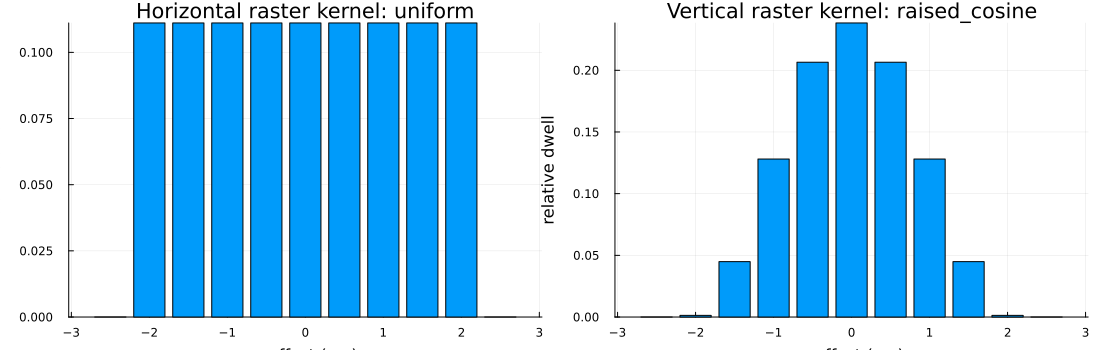

In [31]:
p_kernel_x = bar(
    raster_offsets_x .* 100.0,
    raster_kernel_x;
    xlabel="x offset (cm)", ylabel="relative dwell",
    title="Horizontal raster kernel: $(raster_kind_x)",
    legend=false,
)

p_kernel_y = bar(
    raster_offsets_y .* 100.0,
    raster_kernel_y;
    xlabel="y offset (cm)", ylabel="relative dwell",
    title="Vertical raster kernel: $(raster_kind_y)",
    legend=false,
)

plot(p_kernel_x, p_kernel_y, layout=(1, 2), size=(1100, 350))

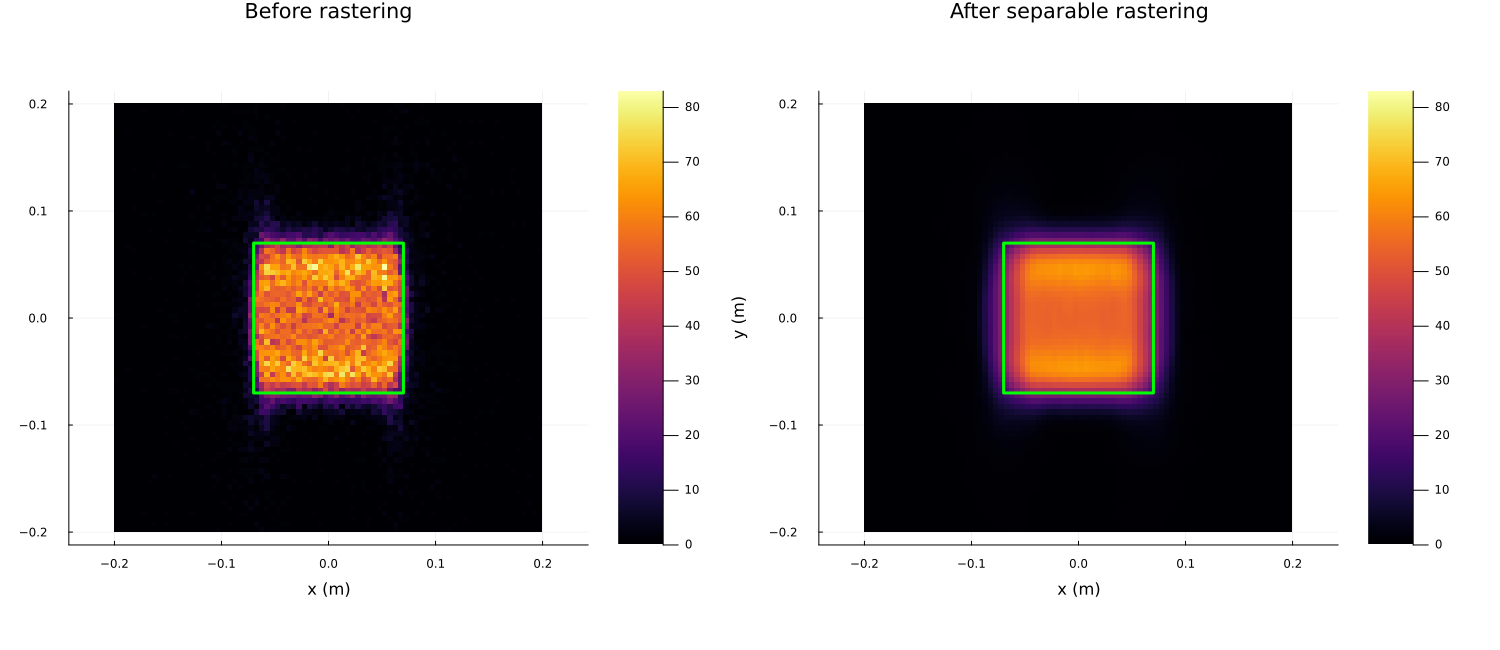

In [32]:
plot_max = maximum(vcat(vec(Float64.(base_H)), vec(rastered_H)))

p_base = profile_heatmap(
    base_H,
    raster_data["x_centers"], raster_data["y_centers"];
    h=target_h, v=target_v,
    title="Before rastering",
    clims=(0.0, plot_max),
)

p_rastered = profile_heatmap(
    rastered_H,
    raster_data["x_centers"], raster_data["y_centers"];
    h=target_h, v=target_v,
    title="After separable rastering",
    clims=(0.0, plot_max),
)

plot(p_base, p_rastered, layout=(1, 2), size=(1500, 650))

### Quick Switching-Function Comparison
<!-- codex-raster-section -->

This scan keeps the raster amplitude fixed at `15%` of the target width and compares several combinations of horizontal and vertical switching functions. Lower `cv_raw` and `top_hat_rmse` indicate a more uniform rectangular fluence, while lower `leakage` indicates less fluence outside the target box.

In [33]:
using Printf
import Markdown

raster_cases = [
    ("uniform / uniform", :uniform, :uniform),
    ("uniform / raised_cosine", :uniform, :raised_cosine),
    ("raised_cosine / uniform", :raised_cosine, :uniform),
    ("triangular / triangular", :triangular, :triangular),
    ("two_point / two_point", :two_point, :two_point),
]

baseline_summary = histogram_uniformity_summary(
    base_H, raster_data["x_edges"], raster_data["y_edges"];
    h=target_h, v=target_v, label="unrastered baseline",
)

raster_case_results = [baseline_summary]
for (label, kind_x, kind_y) in raster_cases
    _, kx = raster_kernel(raster_data["x_centers"]; amplitude=raster_amp_x, kind=kind_x)
    _, ky = raster_kernel(raster_data["y_centers"]; amplitude=raster_amp_y, kind=kind_y)
    H_case = apply_separable_raster(base_H, kx, ky)
    summary = histogram_uniformity_summary(
        H_case, raster_data["x_edges"], raster_data["y_edges"];
        h=target_h, v=target_v, label=label,
    )
    push!(raster_case_results, summary)
end

function fmt_value(x; digits=4)
    return @sprintf("%.*f", digits, Float64(x))
end

function fmt_delta(x; digits=4)
    prefix = x > 0 ? "+" : ""
    return prefix * fmt_value(x; digits=digits)
end

function raster_results_table(results; sort_by=:top_hat_rmse)
    baseline = results[1]
    rastered = sort(results[2:end], by = row -> getproperty(row, sort_by))
    rows = vcat([baseline], rastered)

    lines = String[]
    push!(lines, "Sorted rastered cases by `$(sort_by)`; lower `cv_raw`, `top_hat_rmse`, and `leakage` are generally better.")
    push!(lines, "")
    push!(lines, "| Rank | Switching function | Captured frac | CV raw | Delta CV raw | CV excess | Top-hat RMSE | Delta RMSE | Leakage | Total |")
    push!(lines, "|---:|---|---:|---:|---:|---:|---:|---:|---:|---:|")

    for (i, row) in enumerate(rows)
        rank = i == 1 ? "baseline" : string(i - 1)
        delta_cv = row.cv_raw - baseline.cv_raw
        delta_rmse = row.top_hat_rmse - baseline.top_hat_rmse
        push!(lines,
            "| $(rank) | $(row.label) | $(fmt_value(row.frac)) | $(fmt_value(row.cv_raw)) | $(fmt_delta(delta_cv)) | $(fmt_value(row.cv_excess)) | $(fmt_value(row.top_hat_rmse)) | $(fmt_delta(delta_rmse)) | $(fmt_value(row.leakage)) | $(fmt_value(row.total; digits=1)) |"
        )
    end

    return join(lines, "\n")
end

raster_case_sort_by = :top_hat_rmse
raster_case_table = raster_results_table(raster_case_results; sort_by=raster_case_sort_by)
Markdown.parse(raster_case_table)

Sorted rastered cases by `top_hat_rmse`; lower `cv_raw`, `top_hat_rmse`, and `leakage` are generally better.

|     Rank |      Switching function | Captured frac | CV raw | Delta CV raw | CV excess | Top-hat RMSE | Delta RMSE | Leakage |   Total |
| --------:| -----------------------:| -------------:| ------:| ------------:| ---------:| ------------:| ----------:| -------:| -------:|
| baseline |     unrastered baseline |        0.8752 | 0.1961 |       0.0000 |    0.1424 |       0.2689 |     0.0000 |  0.1248 | 49402.0 |
|        1 | triangular / triangular |        0.8327 | 0.1723 |      -0.0238 |    0.1029 |       0.2958 |    +0.0268 |  0.1673 | 49387.7 |
|        2 | raised_cosine / uniform |        0.8182 | 0.1703 |      -0.0258 |    0.0978 |       0.3122 |    +0.0433 |  0.1818 | 49379.3 |
|        3 | uniform / raised_cosine |        0.8122 | 0.1953 |      -0.0008 |    0.1362 |       0.3254 |    +0.0565 |  0.1878 | 49387.2 |
|        4 |       uniform / uniform |        0.7910 | 0.1960 |      -0.0001 |    0.1352 |       0.3474 |    +0.0785 |  0.2090 | 49377.2 |
|        5 |   two*point / two*point |        0.6429 | 0.3507 |      +0.1546 |    0.3132 |       0.5431 |    +0.2741 |  0.3571 | 49343.5 |


## Nonlinear Optimization Of Triangular Raster Magnitudes
<!-- codex-raster-opt-section -->

This section keeps the horizontal and vertical switching functions fixed as `:triangular`, then optimizes two variables:

- `fraction_x`: horizontal raster magnitude as a fraction of the target-box width.
- `fraction_y`: vertical raster magnitude as a fraction of the target-box width.

The default search range is `0%` to `30%` of the corresponding target width. The earlier hand-picked value, `15%`, sits in the middle of this range.

Because there are two merit quantities, the optimization uses a scalarized score:

```julia
score = cv_weight * (cv_raw / reference_cv_raw) +
        rmse_weight * (top_hat_rmse / reference_top_hat_rmse)
```

The reference values are the unrastered case. The table also reports the Pareto frontier, because the lowest `CV raw` and the lowest `Top-hat RMSE` do not necessarily occur at the same raster magnitudes.

In [34]:
using Printf
import Markdown

function triangular_raster_summary(fraction_x, fraction_y;
                                   label="",
                                   h=target_h, v=target_v)
    amp_x = fraction_x * beam_width_x
    amp_y = fraction_y * beam_width_y

    _, kx = raster_kernel(raster_data["x_centers"]; amplitude=amp_x, kind=:triangular)
    _, ky = raster_kernel(raster_data["y_centers"]; amplitude=amp_y, kind=:triangular)
    H_case = apply_separable_raster(base_H, kx, ky)

    summary = histogram_uniformity_summary(
        H_case, raster_data["x_edges"], raster_data["y_edges"];
        h=h, v=v, label=label,
    )

    return (
        label=label,
        fraction_x=fraction_x,
        fraction_y=fraction_y,
        amplitude_x_m=amp_x,
        amplitude_y_m=amp_y,
        captured_frac=summary.frac,
        cv_raw=summary.cv_raw,
        cv_excess=summary.cv_excess,
        top_hat_rmse=summary.top_hat_rmse,
        leakage=summary.leakage,
        total=summary.total,
        H=H_case,
        kernel_x=kx,
        kernel_y=ky,
    )
end

function add_raster_score(row;
                          cv_ref,
                          rmse_ref,
                          cv_weight=0.5,
                          rmse_weight=0.5)
    score = cv_weight * row.cv_raw / cv_ref +
            rmse_weight * row.top_hat_rmse / rmse_ref

    return merge(row, (
        score=score,
        cv_ratio=row.cv_raw / cv_ref,
        rmse_ratio=row.top_hat_rmse / rmse_ref,
    ))
end

function evaluate_triangular_raster(fraction_x, fraction_y;
                                    cv_ref,
                                    rmse_ref,
                                    cv_weight=0.5,
                                    rmse_weight=0.5,
                                    label="")
    row = triangular_raster_summary(fraction_x, fraction_y; label=label)
    return add_raster_score(row;
                            cv_ref=cv_ref,
                            rmse_ref=rmse_ref,
                            cv_weight=cv_weight,
                            rmse_weight=rmse_weight)
end

function fmt_pct(x; digits=1)
    return @sprintf("%.*f%%", digits, 100 * Float64(x))
end

function fmt_num(x; digits=4)
    return @sprintf("%.*f", digits, Float64(x))
end

function raster_opt_table(rows; sort_by=:score, max_rows=12)
    sorted_rows = sort(rows, by = row -> getproperty(row, sort_by))
    shown_rows = sorted_rows[1:min(max_rows, length(sorted_rows))]

    lines = String[]
    push!(lines, "Sorted by `$(sort_by)`. Lower `score`, `cv_raw`, and `top_hat_rmse` are better; capture/leakage are diagnostics, not part of the default score.")
    push!(lines, "")
    push!(lines, "| Rank | x mag | y mag | Score | CV raw | CV ratio | Top-hat RMSE | RMSE ratio | Captured frac | Leakage |")
    push!(lines, "|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|")

    for (i, row) in enumerate(shown_rows)
        push!(lines,
            "| $(i) | $(fmt_pct(row.fraction_x)) | $(fmt_pct(row.fraction_y)) | $(fmt_num(row.score)) | $(fmt_num(row.cv_raw)) | $(fmt_num(row.cv_ratio)) | $(fmt_num(row.top_hat_rmse)) | $(fmt_num(row.rmse_ratio)) | $(fmt_num(row.captured_frac)) | $(fmt_num(row.leakage)) |"
        )
    end

    return join(lines, "\n")
end

function pareto_front(rows)
    keep = Bool[]
    for row in rows
        dominated = false
        for other in rows
            if other.cv_raw <= row.cv_raw && other.top_hat_rmse <= row.top_hat_rmse &&
               (other.cv_raw < row.cv_raw || other.top_hat_rmse < row.top_hat_rmse)
                dominated = true
                break
            end
        end
        push!(keep, !dominated)
    end
    return sort(rows[keep], by = row -> row.cv_raw)
end

function local_refine_raster(best_row;
                             bounds=(0.0, 0.30),
                             cv_ref,
                             rmse_ref,
                             cv_weight=0.5,
                             rmse_weight=0.5,
                             initial_step=0.02,
                             final_step=0.001)
    lower, upper = bounds
    best = best_row
    history = [best]
    step = initial_step

    while step >= final_step
        candidates = []
        for dx in (-step, 0.0, step), dy in (-step, 0.0, step)
            if dx == 0.0 && dy == 0.0
                continue
            end
            fx = clamp(best.fraction_x + dx, lower, upper)
            fy = clamp(best.fraction_y + dy, lower, upper)
            push!(candidates, evaluate_triangular_raster(
                fx, fy;
                cv_ref=cv_ref, rmse_ref=rmse_ref,
                cv_weight=cv_weight, rmse_weight=rmse_weight,
                label="local refine",
            ))
        end

        trial_best = first(sort(candidates, by = row -> row.score))
        if trial_best.score + 1e-12 < best.score
            best = trial_best
            push!(history, best)
        else
            step /= 2
        end
    end

    return best, history
end

local_refine_raster (generic function with 1 method)

### Run The Magnitude Optimization
<!-- codex-raster-opt-section -->

The first pass is a coarse two-dimensional grid search. The second pass is a small local pattern search starting from the best grid point.

Adjust these knobs if desired:

- `raster_fraction_bounds`: allowed magnitude range, as fraction of target width.
- `raster_fraction_step`: coarse grid step.
- `cv_weight` and `rmse_weight`: tradeoff between in-box flatness and full-field top-hat agreement.

In [35]:
raster_fraction_bounds = (0.00, 0.30)
raster_fraction_step = 0.01
cv_weight = 0.5
rmse_weight = 0.5

reference_row = triangular_raster_summary(0.0, 0.0; label="unrastered reference")
cv_ref = reference_row.cv_raw
rmse_ref = reference_row.top_hat_rmse

fraction_grid = raster_fraction_bounds[1]:raster_fraction_step:raster_fraction_bounds[2]

raster_opt_grid_results = []
for fx in fraction_grid, fy in fraction_grid
    push!(raster_opt_grid_results, evaluate_triangular_raster(
        fx, fy;
        cv_ref=cv_ref, rmse_ref=rmse_ref,
        cv_weight=cv_weight, rmse_weight=rmse_weight,
        label="grid",
    ))
end

best_grid_result = first(sort(raster_opt_grid_results, by = row -> row.score))
best_raster_result, raster_local_history = local_refine_raster(
    best_grid_result;
    bounds=raster_fraction_bounds,
    cv_ref=cv_ref,
    rmse_ref=rmse_ref,
    cv_weight=cv_weight,
    rmse_weight=rmse_weight,
)

raster_opt_results_for_display = vcat([best_raster_result], raster_opt_grid_results)
Markdown.parse(raster_opt_table(raster_opt_results_for_display; sort_by=:score, max_rows=12))

Sorted by `score`. Lower `score`, `cv_raw`, and `top_hat_rmse` are better; capture/leakage are diagnostics, not part of the default score.

| Rank | x mag | y mag |  Score | CV raw | CV ratio | Top-hat RMSE | RMSE ratio | Captured frac | Leakage |
| ----:| -----:| -----:| ------:| ------:| --------:| ------------:| ----------:| -------------:| -------:|
|    1 |  4.1% | 11.0% | 0.9000 | 0.1624 |   0.8280 |       0.2614 |     0.9721 |        0.8636 |  0.1364 |
|    2 |  4.0% | 11.0% | 0.9001 | 0.1626 |   0.8292 |       0.2611 |     0.9710 |        0.8640 |  0.1360 |
|    3 |  4.0% | 12.0% | 0.9003 | 0.1612 |   0.8223 |       0.2631 |     0.9784 |        0.8617 |  0.1383 |
|    4 |  4.0% | 10.0% | 0.9006 | 0.1636 |   0.8341 |       0.2601 |     0.9672 |        0.8653 |  0.1347 |
|    5 |  4.0% | 13.0% | 0.9010 | 0.1604 |   0.8181 |       0.2646 |     0.9840 |        0.8600 |  0.1400 |
|    6 |  5.0% | 10.0% | 0.9016 | 0.1627 |   0.8294 |       0.2619 |     0.9738 |        0.8630 |  0.1370 |
|    7 |  4.0% |  9.0% | 0.9016 | 0.1644 |   0.8384 |       0.2595 |     0.9648 |        0.8663 |  0.1337 |
|    8 |  5.0% | 11.0% | 0.9018 | 0.1619 |   0.8256 |       0.2630 |     0.9780 |        0.8617 |  0.1383 |
|    9 |  4.0% | 14.0% | 0.9019 | 0.1599 |   0.8154 |       0.2658 |     0.9884 |        0.8587 |  0.1413 |
|   10 |  5.0% |  9.0% | 0.9019 | 0.1633 |   0.8328 |       0.2611 |     0.9711 |        0.8639 |  0.1361 |
|   11 |  0.0% | 13.0% | 0.9020 | 0.1618 |   0.8249 |       0.2633 |     0.9792 |        0.8622 |  0.1378 |
|   12 |  1.0% | 13.0% | 0.9020 | 0.1618 |   0.8249 |       0.2633 |     0.9792 |        0.8622 |  0.1378 |


In [36]:
println("Best triangular raster magnitude result")
println("  horizontal magnitude: ", fmt_pct(best_raster_result.fraction_x),
        " = ", fmt_num(best_raster_result.amplitude_x_m; digits=5), " m")
println("  vertical magnitude:   ", fmt_pct(best_raster_result.fraction_y),
        " = ", fmt_num(best_raster_result.amplitude_y_m; digits=5), " m")
println("  score:                ", fmt_num(best_raster_result.score))
println("  CV raw:               ", fmt_num(best_raster_result.cv_raw),
        "  (ratio to unrastered = ", fmt_num(best_raster_result.cv_ratio), ")")
println("  Top-hat RMSE:         ", fmt_num(best_raster_result.top_hat_rmse),
        "  (ratio to unrastered = ", fmt_num(best_raster_result.rmse_ratio), ")")
println("  captured fraction:    ", fmt_num(best_raster_result.captured_frac))
println("  leakage:              ", fmt_num(best_raster_result.leakage))

Best triangular raster magnitude result
  horizontal magnitude: 4.1% = 0.00578 m
  vertical magnitude:   11.0% = 0.01540 m
  score:                0.9000
  CV raw:               0.1624  (ratio to unrastered = 0.8280)
  Top-hat RMSE:         0.2614  (ratio to unrastered = 0.9721)
  captured fraction:    0.8636
  leakage:              0.1364


### Pareto Frontier
<!-- codex-raster-opt-section -->

The table below shows non-dominated grid points. A row is non-dominated if no other tested row has both lower `CV raw` and lower `Top-hat RMSE`.

This is useful when the two objectives disagree. Pick a point on this frontier according to the clinical or experimental priority: lowest in-box variation, best rectangular top-hat match, or a compromise between the two.

In [37]:
raster_pareto_rows = pareto_front(raster_opt_grid_results)
Markdown.parse(raster_opt_table(raster_pareto_rows; sort_by=:cv_raw, max_rows=20))

Sorted by `cv_raw`. Lower `score`, `cv_raw`, and `top_hat_rmse` are better; capture/leakage are diagnostics, not part of the default score.

| Rank | x mag | y mag |  Score | CV raw | CV ratio | Top-hat RMSE | RMSE ratio | Captured frac | Leakage |
| ----:| -----:| -----:| ------:| ------:| --------:| ------------:| ----------:| -------------:| -------:|
|    1 |  0.0% | 23.0% | 0.9289 | 0.1561 |   0.7962 |       0.2855 |     1.0615 |        0.8399 |  0.1601 |
|    2 |  1.0% | 23.0% | 0.9289 | 0.1561 |   0.7962 |       0.2855 |     1.0615 |        0.8399 |  0.1601 |
|    3 |  2.0% | 23.0% | 0.9289 | 0.1561 |   0.7962 |       0.2855 |     1.0615 |        0.8399 |  0.1601 |
|    4 |  3.0% | 23.0% | 0.9289 | 0.1561 |   0.7962 |       0.2855 |     1.0615 |        0.8399 |  0.1601 |
|    5 |  4.0% | 22.0% | 0.9271 | 0.1562 |   0.7968 |       0.2844 |     1.0575 |        0.8406 |  0.1594 |
|    6 |  0.0% | 22.0% | 0.9237 | 0.1563 |   0.7970 |       0.2825 |     1.0504 |        0.8427 |  0.1573 |
|    7 |  1.0% | 22.0% | 0.9237 | 0.1563 |   0.7970 |       0.2825 |     1.0504 |        0.8427 |  0.1573 |
|    8 |  2.0% | 22.0% | 0.9237 | 0.1563 |   0.7970 |       0.2825 |     1.0504 |        0.8427 |  0.1573 |
|    9 |  3.0% | 22.0% | 0.9237 | 0.1563 |   0.7970 |       0.2825 |     1.0504 |        0.8427 |  0.1573 |
|   10 |  4.0% | 21.0% | 0.9223 | 0.1564 |   0.7975 |       0.2816 |     1.0472 |        0.8432 |  0.1568 |
|   11 |  4.0% | 20.0% | 0.9187 | 0.1565 |   0.7982 |       0.2795 |     1.0393 |        0.8451 |  0.1549 |
|   12 |  0.0% | 20.0% | 0.9160 | 0.1568 |   0.7995 |       0.2776 |     1.0325 |        0.8473 |  0.1527 |
|   13 |  1.0% | 20.0% | 0.9160 | 0.1568 |   0.7995 |       0.2776 |     1.0325 |        0.8473 |  0.1527 |
|   14 |  2.0% | 20.0% | 0.9160 | 0.1568 |   0.7995 |       0.2776 |     1.0325 |        0.8473 |  0.1527 |
|   15 |  3.0% | 20.0% | 0.9160 | 0.1568 |   0.7995 |       0.2776 |     1.0325 |        0.8473 |  0.1527 |
|   16 |  4.0% | 19.0% | 0.9148 | 0.1568 |   0.7996 |       0.2770 |     1.0299 |        0.8475 |  0.1525 |
|   17 |  0.0% | 19.0% | 0.9125 | 0.1572 |   0.8016 |       0.2752 |     1.0233 |        0.8496 |  0.1504 |
|   18 |  1.0% | 19.0% | 0.9125 | 0.1572 |   0.8016 |       0.2752 |     1.0233 |        0.8496 |  0.1504 |
|   19 |  2.0% | 19.0% | 0.9125 | 0.1572 |   0.8016 |       0.2752 |     1.0233 |        0.8496 |  0.1504 |
|   20 |  3.0% | 19.0% | 0.9125 | 0.1572 |   0.8016 |       0.2752 |     1.0233 |        0.8496 |  0.1504 |


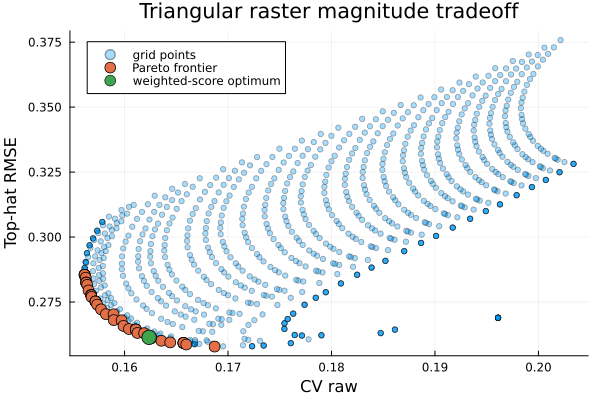

In [38]:
cv_values = [row.cv_raw for row in raster_opt_grid_results]
rmse_values = [row.top_hat_rmse for row in raster_opt_grid_results]

p_tradeoff = scatter(
    cv_values, rmse_values;
    xlabel="CV raw",
    ylabel="Top-hat RMSE",
    title="Triangular raster magnitude tradeoff",
    label="grid points",
    markersize=3,
    alpha=0.35,
)

scatter!(p_tradeoff,
    [row.cv_raw for row in raster_pareto_rows],
    [row.top_hat_rmse for row in raster_pareto_rows];
    label="Pareto frontier",
    markersize=6,
)

scatter!(p_tradeoff,
    [best_raster_result.cv_raw],
    [best_raster_result.top_hat_rmse];
    label="weighted-score optimum",
    markersize=8,
)

p_tradeoff

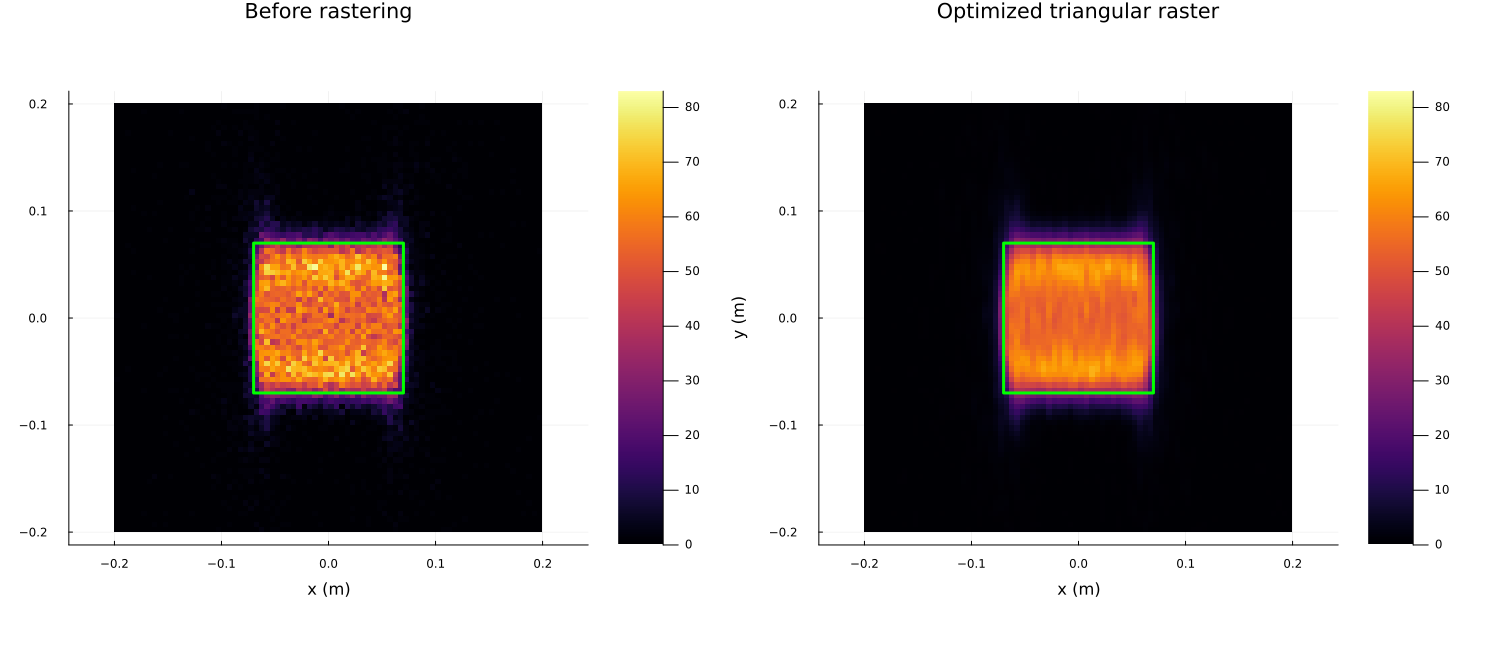

In [39]:
plot_max_opt = maximum(vcat(vec(Float64.(base_H)), vec(best_raster_result.H)))

p_unrastered_opt = profile_heatmap(
    base_H,
    raster_data["x_centers"], raster_data["y_centers"];
    h=target_h, v=target_v,
    title="Before rastering",
    clims=(0.0, plot_max_opt),
)

p_best_raster_opt = profile_heatmap(
    best_raster_result.H,
    raster_data["x_centers"], raster_data["y_centers"];
    h=target_h, v=target_v,
    title="Optimized triangular raster",
    clims=(0.0, plot_max_opt),
)

plot(p_unrastered_opt, p_best_raster_opt, layout=(1, 2), size=(1500, 650))

## Raster-Aware Bayesian Optimization Of The Optical Elements
<!-- codex-rastered-optics-section -->

The earlier Bayesian optimization tuned the optical elements using the static beam profile, and rastering was applied afterward. This section repeats the optical-element optimization, but now each trial point is evaluated with the optimized triangular/triangular raster already applied.

For every Xopt trial:

1. Set `Q3.Bn1`, `Q4.Bn1`, `O1.Bn3`, and `O2.Bn3`.
2. Track the particles through SciBmad.
3. Histogram the tracked beam.
4. Apply the two optimized 1D triangular raster convolutions.
5. Score the rastered fluence using `CV raw` and `Top-hat RMSE`.

The raster amplitudes are held fixed at the best horizontal and vertical values found in the previous raster-magnitude optimization. Only the optical elements are reoptimized here.

In [40]:
using Printf
import Markdown

rastered_optics_fraction_x = best_raster_result.fraction_x
rastered_optics_fraction_y = best_raster_result.fraction_y
rastered_optics_amp_x = best_raster_result.amplitude_x_m
rastered_optics_amp_y = best_raster_result.amplitude_y_m

function summarize_rastered_optics_bunch(sim_coords; label="")
    data = hist(sim_coords, nx=optics_nx, ny=optics_ny, make_plot=false)

    _, kx = raster_kernel(
        data["x_centers"];
        amplitude=rastered_optics_amp_x,
        kind=:triangular,
    )
    _, ky = raster_kernel(
        data["y_centers"];
        amplitude=rastered_optics_amp_y,
        kind=:triangular,
    )

    H_rastered = apply_separable_raster(data["weights"], kx, ky)
    summary = histogram_uniformity_summary(
        H_rastered, data["x_edges"], data["y_edges"];
        h=target_h, v=target_v, label=label,
    )

    return (
        label=label,
        data=data,
        H=H_rastered,
        captured_frac=summary.frac,
        cv_raw=summary.cv_raw,
        cv_excess=summary.cv_excess,
        top_hat_rmse=summary.top_hat_rmse,
        leakage=summary.leakage,
        total=summary.total,
    )
end

rastered_optics_reference = summarize_rastered_optics_bunch(
    raster_source;
    label="optimized optics + optimized raster reference",
)

rastered_optics_cv_ref = max(rastered_optics_reference.cv_raw, eps(Float64))
rastered_optics_rmse_ref = max(rastered_optics_reference.top_hat_rmse, eps(Float64))

rastered_optics_cv_weight = 0.50
rastered_optics_rmse_weight = 0.50
rastered_optics_balance_weight = 0.15
rastered_optics_capture_goal = optics_capture_goal
rastered_optics_leakage_goal = optics_leakage_goal
rastered_optics_capture_penalty_weight = optics_capture_penalty_weight
rastered_optics_leakage_penalty_weight = optics_leakage_penalty_weight

function rastered_optics_score(row)
    cv_term = row.cv_raw / rastered_optics_cv_ref
    rmse_term = row.top_hat_rmse / rastered_optics_rmse_ref
    balance_penalty = rastered_optics_balance_weight * abs(cv_term - rmse_term)
    capture_shortfall = max(rastered_optics_capture_goal - row.captured_frac, 0.0)
    leakage_excess = max(row.leakage - rastered_optics_leakage_goal, 0.0)
    capture_penalty = rastered_optics_capture_penalty_weight * capture_shortfall^2
    leakage_penalty = rastered_optics_leakage_penalty_weight * leakage_excess^2

    objective = rastered_optics_cv_weight * cv_term +
                rastered_optics_rmse_weight * rmse_term +
                balance_penalty +
                capture_penalty +
                leakage_penalty

    return (
        objective=objective,
        cv_term=cv_term,
        rmse_term=rmse_term,
        balance_penalty=balance_penalty,
        capture_shortfall=capture_shortfall,
        leakage_excess=leakage_excess,
        capture_penalty=capture_penalty,
        leakage_penalty=leakage_penalty,
    )
end

function func_rastered_optics(x)
    Q3.Bn1 =  x["x1"]
    Q4.Bn1 =  x["x2"]
    O1.Bn3 = -x["x3"]
    O2.Bn3 =  x["x3"]

    tmp = track(nsrl, coords)
    row = summarize_rastered_optics_bunch(tmp; label="rastered optics trial")
    score = rastered_optics_score(row)

    return pydict(Dict(
        "f" => score.objective,
        "f_cv_term" => score.cv_term,
        "f_rmse_term" => score.rmse_term,
        "f_balance_penalty" => score.balance_penalty,
        "f_capture_penalty" => score.capture_penalty,
        "f_leakage_penalty" => score.leakage_penalty,
        "frac" => row.captured_frac,
        "cv_raw" => row.cv_raw,
        "cv_excess" => row.cv_excess,
        "top_hat_rmse" => row.top_hat_rmse,
        "leakage" => row.leakage,
        "capture_shortfall" => score.capture_shortfall,
        "leakage_excess" => score.leakage_excess,
        "raster_fraction_x" => rastered_optics_fraction_x,
        "raster_fraction_y" => rastered_optics_fraction_y,
    ))
end

println("Using fixed triangular raster magnitudes during optics reoptimization:")
println("  horizontal: ", fmt_pct(rastered_optics_fraction_x),
        " = ", fmt_num(rastered_optics_amp_x; digits=5), " m")
println("  vertical:   ", fmt_pct(rastered_optics_fraction_y),
        " = ", fmt_num(rastered_optics_amp_y; digits=5), " m")

Using fixed triangular raster magnitudes during optics reoptimization:
  horizontal: 4.1% = 0.00578 m
  vertical:   11.0% = 0.01540 m


In [41]:
rastered_evaluator = Py(Evaluator(; :function => func_rastered_optics))

rastered_generator = ExpectedImprovementGenerator(; :vocs => vocs, :turbo_controller => "optimize")
rastered_generator.gp_constructor.use_low_noise_prior = true

X_rastered = Xopt(; :evaluator => rastered_evaluator,
                  :generator => rastered_generator,
                  :vocs => vocs)

seed_x1 = @isdefined(jl_dict) ? value_as_float(jl_dict["x1"]) : 3.0
seed_x2 = @isdefined(jl_dict) ? value_as_float(jl_dict["x2"]) : -3.0
seed_x3 = @isdefined(jl_dict) ? value_as_float(jl_dict["x3"]) : 1.75e3

_rastered_seed = pydict(Dict(
    "x1" => [seed_x1, 3.0, 2.5, 3.5, 2.0, 4.0],
    "x2" => [seed_x2, -3.0, -3.5, -2.5, -4.0, -2.0],
    "x3" => [seed_x3, 1.75e3, 1.50e3, 2.00e3, 1.25e3, 2.25e3],
))

X_rastered.evaluate_data(_rastered_seed)

,x1,x2,x3,raster_fraction_y,f,leakage,raster_fraction_x,f_capture_penalty,cv_raw,capture_shortfall,f_leakage_penalty,leakage_excess,top_hat_rmse,frac,f_balance_penalty,f_cv_term,cv_excess,f_rmse_term,xopt_runtime,xopt_error
0,2.954992,-2.942486,1601.411591,0.11,1.000000,0.136439,0.04125,0.000000,0.162371,0.000000,0.000000,0.000000,0.261410,0.863561,0.000000,1.000000,0.089165,1.000000,0.170404,False
1,3.000000,-3.000000,1750.000000,0.11,1.219958,0.112500,0.04125,0.000000,0.216244,0.000000,0.000000,0.000000,0.264616,0.887500,0.047929,1.331793,0.169735,1.012265,0.061826,False
2,2.500000,-3.500000,1500.000000,0.11,2.381173,0.301937,0.04125,0.002888,0.435707,0.021937,0.001444,0.021937,0.472502,0.698063,0.131383,2.683403,0.396731,1.807514,0.064635,False
3,3.500000,-2.500000,2000.000000,0.11,9.855026,0.045778,0.04125,0.000000,1.865945,0.000000,0.000000,0.000000,1.781554,0.954222,0.701504,11.491868,1.860287,6.815176,0.064279,False
4,2.000000,-4.000000,1250.000000,0.11,2.880844,0.393652,0.04125,0.077500,0.502170,0.113652,0.038750,0.113652,0.563387,0.606348,0.140632,3.092735,0.441677,2.155186,0.064199,False
5,4.000000,-2.000000,2250.000000,0.11,4.410810,0.194639,0.04125,0.000000,0.858812,0.000000,0.000000,0.000000,0.726594,0.805361,0.376451,5.289197,0.840979,2.779521,0.065027,False


In [42]:
rastered_start_time = time()
@time for i in 1:100
    X_rastered.step()
    if i%10 == 0
        println("$i raster-aware optics steps complete: $(time() - rastered_start_time) seconds")
    end
end
println("Raster-aware Bayesian optimization complete")

10 raster-aware optics steps complete: 40.23529601097107 seconds
20 raster-aware optics steps complete: 67.85370397567749 seconds
30 raster-aware optics steps complete: 110.72581791877747 seconds
40 raster-aware optics steps complete: 129.8551208972931 seconds
50 raster-aware optics steps complete: 150.62074184417725 seconds
60 raster-aware optics steps complete: 176.20173597335815 seconds
70 raster-aware optics steps complete: 221.99640083312988 seconds
80 raster-aware optics steps complete: 239.4627239704132 seconds
90 raster-aware optics steps complete: 260.159884929657 seconds
100 raster-aware optics steps complete: 278.41224098205566 seconds
278.388934 seconds (105.83 k allocations: 838.241 MiB, 0.10% gc time)
Raster-aware Bayesian optimization complete


In [43]:
rastered_mask = X_rastered.data["f"] .== X_rastered.data["f"].min()
rastered_ind = X_rastered.data["f"].index[rastered_mask][0]
rastered_py_series = X_rastered.data.loc[rastered_ind]

rastered_keys = collect(rastered_py_series.index)
rastered_values = collect(rastered_py_series.values)

rastered_jl_dict = Dict(string(k) => v for (k, v) in zip(rastered_keys, rastered_values))

Dict{String, Py} with 20 entries:
  "raster_fraction_y" => np.float64(0.11)
  "f"                 => np.float64(0.9795010704800753)
  "leakage"           => np.float64(0.1480267467101426)
  "raster_fraction_x" => np.float64(0.04125)
  "x2"                => np.float64(-2.9568961041937234)
  "f_capture_penalty" => np.float64(0.0)
  "cv_raw"            => np.float64(0.14122663952032435)
  "capture_shortfall" => np.float64(0.0)
  "f_leakage_penalty" => np.float64(0.0)
  "x3"                => np.float64(1531.8861191721385)
  "leakage_excess"    => np.float64(0.0)
  "xopt_runtime"      => np.float64(0.06741734687238932)
  "top_hat_rmse"      => np.float64(0.27149575208910987)
  "frac"              => np.float64(0.8519732532898575)
  "x1"                => np.float64(2.966976395098434)
  "f_balance_penalty" => np.float64(0.02532072024062848)
  "xopt_error"        => np.False_
  "f_cv_term"         => np.float64(0.8697779494373519)
  "cv_excess"         => np.float64(0.03655150592788787)
  "

In [44]:
Q3.Bn1 =  value_as_float(rastered_jl_dict["x1"])
Q4.Bn1 =  value_as_float(rastered_jl_dict["x2"])
O1.Bn3 = -value_as_float(rastered_jl_dict["x3"])
O2.Bn3 =  value_as_float(rastered_jl_dict["x3"])

rastered_optics_tmp = track(nsrl, coords)
rastered_optics_final = summarize_rastered_optics_bunch(
    rastered_optics_tmp;
    label="raster-aware optics + optimized raster",
)
rastered_optics_final_score = rastered_optics_score(rastered_optics_final)

println("Best raster-aware optics settings:")
println("  Q3.Bn1 = ", fmt_num(value_as_float(rastered_jl_dict["x1"]); digits=5))
println("  Q4.Bn1 = ", fmt_num(value_as_float(rastered_jl_dict["x2"]); digits=5))
println("  O1.Bn3 = ", fmt_num(-value_as_float(rastered_jl_dict["x3"]); digits=5))
println("  O2.Bn3 = ", fmt_num(value_as_float(rastered_jl_dict["x3"]); digits=5))
println()
println("Raster-aware final metrics:")
println("  score:        ", fmt_num(rastered_optics_final_score.objective))
println("  CV raw:       ", fmt_num(rastered_optics_final.cv_raw))
println("  Top-hat RMSE: ", fmt_num(rastered_optics_final.top_hat_rmse))
println("  captured:     ", fmt_num(rastered_optics_final.captured_frac))
println("  leakage:      ", fmt_num(rastered_optics_final.leakage))

Best raster-aware optics settings:
  Q3.Bn1 = 2.96698
  Q4.Bn1 = -2.95690
  O1.Bn3 = -1531.88612
  O2.Bn3 = 1531.88612

Raster-aware final metrics:
  score:        0.9795
  CV raw:       0.1412
  Top-hat RMSE: 0.2715
  captured:     0.8520
  leakage:      0.1480


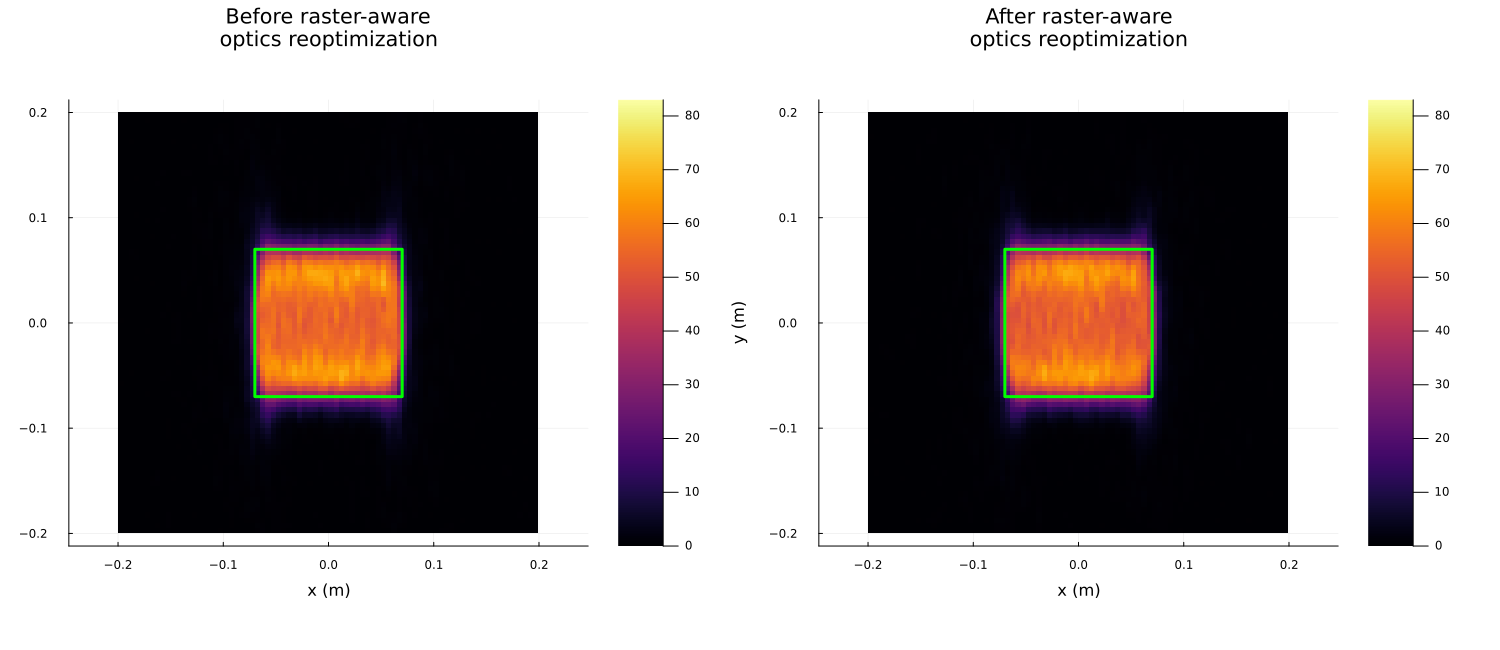

In [45]:
plot_max_rastered_optics = maximum(vcat(vec(Float64.(base_H)), vec(best_raster_result.H), vec(rastered_optics_final.H)))

p_previous_final = profile_heatmap(
    best_raster_result.H,
    raster_data["x_centers"], raster_data["y_centers"];
    h=target_h, v=target_v,
    title="Before raster-aware\noptics reoptimization",
    clims=(0.0, plot_max_rastered_optics),
)

p_rastered_final = profile_heatmap(
    rastered_optics_final.H,
    rastered_optics_final.data["x_centers"], rastered_optics_final.data["y_centers"];
    h=target_h, v=target_v,
    title="After raster-aware\noptics reoptimization",
    clims=(0.0, plot_max_rastered_optics),
)

plot(p_previous_final, p_rastered_final, layout=(1, 2), size=(1500, 650))

## Summary: Uniformity Improvement Through The Workflow
<!-- codex-final-uniformity-summary -->

This final section compares the two main uniformity metrics at the key stages of the workflow:

1. **Initial optics attempt**: the tracked beam before the nonlinear Xopt magnet optimization.
2. **Optimized nonlinear optics**: the best magnet setting from the first Xopt pass, before rastering.
3. **15% triangular raster**: a fixed weak triangular/triangular raster at the original suggested magnitude.
4. **Optimized raster magnitudes**: triangular/triangular raster with horizontal and vertical magnitudes chosen by the raster-magnitude optimization.
5. **Raster-aware optics reoptimization**: a second Xopt pass over the optical elements, with the optimized triangular raster applied inside every SciBmad trial evaluation.

The two columns to focus on are:

- `CV raw`: coefficient of variation of binned fluence inside the target rectangle. Lower means flatter dose inside the box.
- `Top-hat RMSE`: full-field normalized error relative to an ideal rectangular top-hat fluence. Lower means closer to the intended rectangular shape, including leakage outside the box.

The percentage reduction columns are measured relative to the **initial optics attempt**. The last row is now the workflow's final result.

In [46]:
using Printf
import Markdown

function summarize_histogram_stage(label, H, x_edges, y_edges;
                                   h=target_h, v=target_v)
    summary = histogram_uniformity_summary(H, x_edges, y_edges; h=h, v=v, label=label)
    return (
        label=label,
        captured_frac=summary.frac,
        cv_raw=summary.cv_raw,
        top_hat_rmse=summary.top_hat_rmse,
        leakage=summary.leakage,
        total=summary.total,
    )
end

function percent_reduction(new_value, old_value)
    return 100.0 * (old_value - new_value) / old_value
end

function fmt_summary_value(x; digits=4)
    return @sprintf("%.*f", digits, Float64(x))
end

function fmt_summary_percent(x; digits=1)
    prefix = x >= 0 ? "" : "-"
    return prefix * @sprintf("%.*f%%", digits, abs(Float64(x)))
end

# Stage 1: original tracked bunch before the Xopt magnet optimization.
initial_data = hist(bunch, nx=80, ny=80, make_plot=false)
initial_stage = summarize_histogram_stage(
    "1. Initial optics attempt",
    initial_data["weights"], initial_data["x_edges"], initial_data["y_edges"],
)

# Stage 2: optimized magnet settings, before rastering. This is built in the raster section.
optimized_optics_stage = summarize_histogram_stage(
    "2. Optimized nonlinear optics",
    base_H, raster_data["x_edges"], raster_data["y_edges"],
)

# Stage 3: fixed 15% triangular/triangular weak raster.
triangular_15_stage_raw = triangular_raster_summary(
    0.15, 0.15; label="3. 15% triangular raster",
)
triangular_15_stage = (
    label=triangular_15_stage_raw.label,
    captured_frac=triangular_15_stage_raw.captured_frac,
    cv_raw=triangular_15_stage_raw.cv_raw,
    top_hat_rmse=triangular_15_stage_raw.top_hat_rmse,
    leakage=triangular_15_stage_raw.leakage,
    total=triangular_15_stage_raw.total,
)

# Stage 4: optimized triangular/triangular raster magnitudes, applied after the first optics optimization.
optimized_raster_stage = (
    label="4. Optimized raster magnitudes",
    captured_frac=best_raster_result.captured_frac,
    cv_raw=best_raster_result.cv_raw,
    top_hat_rmse=best_raster_result.top_hat_rmse,
    leakage=best_raster_result.leakage,
    total=best_raster_result.total,
)

# Stage 5: second optics optimization with the optimized raster applied inside every trial.
raster_aware_final_stage = (
    label="5. Raster-aware optics reoptimization",
    captured_frac=rastered_optics_final.captured_frac,
    cv_raw=rastered_optics_final.cv_raw,
    top_hat_rmse=rastered_optics_final.top_hat_rmse,
    leakage=rastered_optics_final.leakage,
    total=rastered_optics_final.total,
)

final_stage = raster_aware_final_stage

uniformity_summary_rows = [
    initial_stage,
    optimized_optics_stage,
    triangular_15_stage,
    optimized_raster_stage,
    final_stage,
]

initial_cv = initial_stage.cv_raw
initial_rmse = initial_stage.top_hat_rmse

summary_lines = String[]
push!(summary_lines, "| Stage | Captured frac | CV raw | CV raw reduction | Top-hat RMSE | RMSE reduction | Leakage |")
push!(summary_lines, "|---|---:|---:|---:|---:|---:|---:|")

for row in uniformity_summary_rows
    cv_reduction = percent_reduction(row.cv_raw, initial_cv)
    rmse_reduction = percent_reduction(row.top_hat_rmse, initial_rmse)
    push!(summary_lines,
        "| $(row.label) | $(fmt_summary_value(row.captured_frac)) | $(fmt_summary_value(row.cv_raw)) | $(fmt_summary_percent(cv_reduction)) | $(fmt_summary_value(row.top_hat_rmse)) | $(fmt_summary_percent(rmse_reduction)) | $(fmt_summary_value(row.leakage)) |"
    )
end

Markdown.parse(join(summary_lines, "\n"))

|                                 Stage | Captured frac | CV raw | CV raw reduction | Top-hat RMSE | RMSE reduction | Leakage |
| -------------------------------------:| -------------:| ------:| ----------------:| ------------:| --------------:| -------:|
|             1. Initial optics attempt |        0.8880 | 0.2631 |             0.0% |       0.2936 |           0.0% |  0.1120 |
|         2. Optimized nonlinear optics |        0.8752 | 0.1961 |            25.5% |       0.2689 |           8.4% |  0.1248 |
|              3. 15% triangular raster |        0.8327 | 0.1723 |            34.5% |       0.2958 |          -0.7% |  0.1673 |
|        4. Optimized raster magnitudes |        0.8636 | 0.1624 |            38.3% |       0.2614 |          11.0% |  0.1364 |
| 5. Raster-aware optics reoptimization |        0.8520 | 0.1412 |            46.3% |       0.2715 |           7.5% |  0.1480 |


In [47]:
cv_total_reduction = percent_reduction(final_stage.cv_raw, initial_stage.cv_raw)
rmse_total_reduction = percent_reduction(final_stage.top_hat_rmse, initial_stage.top_hat_rmse)
cv_optics_reduction = percent_reduction(optimized_optics_stage.cv_raw, initial_stage.cv_raw)
rmse_optics_reduction = percent_reduction(optimized_optics_stage.top_hat_rmse, initial_stage.top_hat_rmse)
cv_raster_reduction = percent_reduction(optimized_raster_stage.cv_raw, optimized_optics_stage.cv_raw)
rmse_raster_reduction = percent_reduction(optimized_raster_stage.top_hat_rmse, optimized_optics_stage.top_hat_rmse)
cv_raster_aware_reduction = percent_reduction(final_stage.cv_raw, optimized_raster_stage.cv_raw)
rmse_raster_aware_reduction = percent_reduction(final_stage.top_hat_rmse, optimized_raster_stage.top_hat_rmse)

println("Overall improvement from initial optics attempt to final result:")
println("  CV raw reduction:       ", fmt_summary_percent(cv_total_reduction),
        "  (", fmt_summary_value(initial_stage.cv_raw), " -> ", fmt_summary_value(final_stage.cv_raw), ")")
println("  Top-hat RMSE reduction: ", fmt_summary_percent(rmse_total_reduction),
        "  (", fmt_summary_value(initial_stage.top_hat_rmse), " -> ", fmt_summary_value(final_stage.top_hat_rmse), ")")
println()
println("Contribution of first nonlinear optics optimization:")
println("  CV raw reduction:       ", fmt_summary_percent(cv_optics_reduction))
println("  Top-hat RMSE reduction: ", fmt_summary_percent(rmse_optics_reduction))
println()
println("Additional contribution of optimized triangular raster magnitudes:")
println("  CV raw reduction from optimized optics:       ", fmt_summary_percent(cv_raster_reduction))
println("  Top-hat RMSE reduction from optimized optics: ", fmt_summary_percent(rmse_raster_reduction))
println()
println("Additional contribution of raster-aware optics reoptimization:")
println("  CV raw reduction from optimized raster stage:       ", fmt_summary_percent(cv_raster_aware_reduction))
println("  Top-hat RMSE reduction from optimized raster stage: ", fmt_summary_percent(rmse_raster_aware_reduction))
println()
println("Fixed triangular raster magnitudes used in the final optics pass:")
println("  horizontal: ", fmt_summary_percent(best_raster_result.fraction_x),
        " of target width = ", fmt_summary_value(best_raster_result.amplitude_x_m; digits=5), " m")
println("  vertical:   ", fmt_summary_percent(best_raster_result.fraction_y),
        " of target width = ", fmt_summary_value(best_raster_result.amplitude_y_m; digits=5), " m")
println()
println("Final raster-aware optical settings:")
println("  Q3.Bn1 = ", fmt_summary_value(value_as_float(rastered_jl_dict["x1"]); digits=5))
println("  Q4.Bn1 = ", fmt_summary_value(value_as_float(rastered_jl_dict["x2"]); digits=5))
println("  O1.Bn3 = ", fmt_summary_value(-value_as_float(rastered_jl_dict["x3"]); digits=5))
println("  O2.Bn3 = ", fmt_summary_value(value_as_float(rastered_jl_dict["x3"]); digits=5))

Overall improvement from initial optics attempt to final result:
  CV raw reduction:       46.3%  (0.2631 -> 0.1412)
  Top-hat RMSE reduction: 7.5%  (0.2936 -> 0.2715)

Contribution of first nonlinear optics optimization:
  CV raw reduction:       25.5%
  Top-hat RMSE reduction: 8.4%

Additional contribution of optimized triangular raster magnitudes:
  CV raw reduction from optimized optics:       17.2%
  Top-hat RMSE reduction from optimized optics: 2.8%

Additional contribution of raster-aware optics reoptimization:
  CV raw reduction from optimized raster stage:       13.0%
  Top-hat RMSE reduction from optimized raster stage: -3.9%

Fixed triangular raster magnitudes used in the final optics pass:
  horizontal: 0.0% of target width = 0.00578 m
  vertical:   0.1% of target width = 0.01540 m

Final raster-aware optical settings:
  Q3.Bn1 = 2.96698
  Q4.Bn1 = -2.95690
  O1.Bn3 = -1531.88612
  O2.Bn3 = 1531.88612


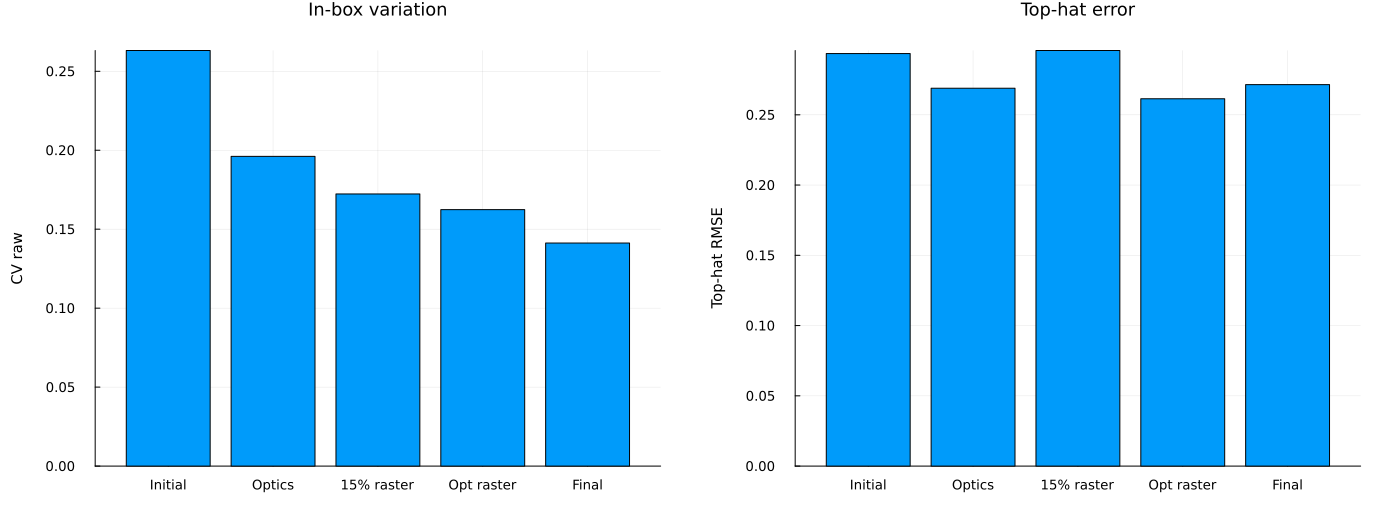

In [48]:
stage_names = ["Initial", "Optics", "15% raster", "Opt raster", "Final"]
cv_stage_values = [row.cv_raw for row in uniformity_summary_rows]
rmse_stage_values = [row.top_hat_rmse for row in uniformity_summary_rows]

summary_plot_margin = 8 * Plots.mm
p_cv_summary = bar(
    stage_names, cv_stage_values;
    ylabel="CV raw",
    title="In-box variation",
    titlefontsize=12,
    tickfontsize=9,
    guidefontsize=10,
    legend=false,
    xrotation=0,
    bottom_margin=summary_plot_margin,
    top_margin=summary_plot_margin,
    left_margin=summary_plot_margin,
)

p_rmse_summary = bar(
    stage_names, rmse_stage_values;
    ylabel="Top-hat RMSE",
    title="Top-hat error",
    titlefontsize=12,
    tickfontsize=9,
    guidefontsize=10,
    legend=false,
    xrotation=0,
    bottom_margin=summary_plot_margin,
    top_margin=summary_plot_margin,
    left_margin=summary_plot_margin,
)

plot(
    p_cv_summary, p_rmse_summary;
    layout=(1, 2),
    size=(1400, 520),
    margin=summary_plot_margin,
)

### Reading The Summary
<!-- codex-final-uniformity-summary -->

A good final result should reduce both `CV raw` and `Top-hat RMSE`. If one improves while the other worsens, the result is a tradeoff rather than a clear improvement.

`Captured frac` and `Leakage` are included as guardrails. Rastering can flatten the target region by spreading fluence, but too much spreading can move dose outside the rectangle. The final raster-aware optics pass is meant to let the optical elements compensate for the fixed raster, rather than treating rastering as only a post-processing step.